#### EXPLAINABLE DEEPFAKE AUDIO DETECTION WITH CONFIDENCE CALIBRATION

1. Phase 1 (Data Prep & RF Baseline)
2. Phase 2 (CNN+BiLSTM)
3. Phase 3 (ResNet18)
4. Phase 4 (LCNN)
5. Phase 5 (Calibration)
6. Phase 6 (XAI)
7. Phase 7 (Reporting & Backup)

#### PHASE 1

###### Connect the Google Drive & Extract Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Locate the zip path in your Google Drive and unzip it to local Colab instance
zip_path = "/content/drive/MyDrive/LA_Subset.zip"

import subprocess
import os
print("Extracting dataset zip to local scratch disk...")
subprocess.run(['7z', 'x', zip_path, '-o/content/LA_Subset', '-y'])
print("Extraction complete.")

Mounted at /content/drive
Extracting dataset zip to local scratch disk...
Extraction complete.


#### Install Dependencies & Global Configuration



In [3]:
!pip install librosa shap scikit-learn pandas numpy matplotlib seaborn reportlab soundfile joblib --quiet
import os, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import librosa
import librosa.display
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             roc_curve, precision_recall_curve)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.1 MB/s eta 0:00:00


In [4]:
# ── Directory Paths ───────────────────────────────────────────────────────────
DATASET_BASE = "/content/LA_Subset/LA_Subset"
OUTPUT_DIR   = "/content/project_outputs"
MODEL_DIR    = os.path.join(OUTPUT_DIR, "models")
PLOT_DIR     = os.path.join(OUTPUT_DIR, "plots")
REPORT_DIR   = os.path.join(OUTPUT_DIR, "reports")
FEATURE_DIR  = os.path.join(OUTPUT_DIR, "features")

In [5]:
# ── Audio & MFCC Parameters ──────────────────────────────────────────────────
SAMPLE_RATE    = 16000
PRE_EMPHASIS   = 0.97
SILENCE_TOP_DB = 20
N_MFCC         = 40
WINDOW_MS      = 25
HOP_MS         = 10
N_FFT          = int(SAMPLE_RATE * (WINDOW_MS / 1000.0))  # 400
HOP_LENGTH     = int(SAMPLE_RATE * (HOP_MS   / 1000.0))  # 160
WIN_LENGTH     = N_FFT
WINDOW_TYPE    = 'hamming'

In [6]:
# ── Stratified Sampler Parameters ────────────────────────────────────────────
TRAIN_BONAFIDE_SIZE = 1500
TRAIN_SPOOF_SIZE    = 1500
VAL_BONAFIDE_SIZE   = 500
VAL_SPOOF_SIZE      = 500
RANDOM_STATE        = 42

In [ ]:
# ── Create output directories ─────────────────────────────────────────────────
for path in [OUTPUT_DIR, MODEL_DIR, PLOT_DIR, REPORT_DIR, FEATURE_DIR]:
    os.makedirs(path, exist_ok=True)
print("✅ Configuration set & output directories created.")
print(f"   Dataset base : {DATASET_BASE}")
print(f"   Outputs root : {OUTPUT_DIR}")

✅ Configuration set & output directories created.
   Dataset base : /content/LA_Subset/LA_Subset
   Outputs root : /content/project_outputs


#### Helper Functions (Dataset / Features / Evaluate / Model)

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# DATASET HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def parse_protocol_file(file_path):
    """Parses ASVspoof 2019 LA protocol file into a DataFrame."""
    df = pd.read_csv(file_path, sep=r'\s+', header=None,
                     names=['speaker_id', 'file_id', 'dummy', 'attack_id', 'label'])
    df['label_num'] = df['label'].map({'bonafide': 0, 'spoof': 1})
    return df

def get_audio_path(file_id, subset):
    """Returns absolute path to a .flac file given its ID and split name."""
    if subset == 'train':
        folder = "ASVspoof2019_LA_train"
    elif subset in ['dev', 'val']:
        folder = "ASVspoof2019_LA_dev"
    else:
        raise ValueError(f"Unknown subset: {subset}")
    return os.path.join(DATASET_BASE, folder, "flac", f"{file_id}.flac")

def pre_emphasis_filter(y, alpha=PRE_EMPHASIS):
    """Applies a pre-emphasis high-pass filter to boost high frequencies."""
    if len(y) == 0:
        return y
    return np.append(y[0], y[1:] - alpha * y[:-1])

def preprocess_audio(file_path):
    """
    Full audio preprocessing pipeline:
      1. Load at fixed sample rate
      2. Pre-emphasis filter
      3. Silence trimming (with fallback if result is empty)
      4. Peak normalisation
    """
    y, sr     = librosa.load(file_path, sr=SAMPLE_RATE)
    y_pre     = pre_emphasis_filter(y)                           # step 2
    y_trimmed, _ = librosa.effects.trim(y_pre, top_db=SILENCE_TOP_DB)  # step 3
    if len(y_trimmed) == 0:                                      # fallback
        y_trimmed = y_pre
    max_val = np.max(np.abs(y_trimmed))                          # step 4
    if max_val > 0:
        y_norm = y_trimmed / max_val
    else:
        y_norm = y_trimmed
    return y_norm

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE EXTRACTION
# ─────────────────────────────────────────────────────────────────────────────

def extract_mfcc_features_1d(y):
    """
    Extracts 1D aggregated MFCC features: [mean(40), std(40)] → shape (80,).
    Used for Random Forest.
    """
    mfccs = librosa.feature.mfcc(
        y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC, n_fft=N_FFT,
        hop_length=HOP_LENGTH, win_length=WIN_LENGTH, window=WINDOW_TYPE
    )
    return np.concatenate([np.mean(mfccs, axis=1), np.std(mfccs, axis=1)])

def extract_subset_features_1d(subset_df, subset_name):
    """
    Loops over a metadata DataFrame, preprocesses each audio file,
    extracts 1D MFCC features, and returns (X, y) arrays.
    """
    X, y = [], []
    start = time.time()
    for i, (idx, row) in enumerate(subset_df.iterrows()):
        file_path = get_audio_path(row['file_id'], subset_name)
        try:
            y_audio = preprocess_audio(file_path)
            X.append(extract_mfcc_features_1d(y_audio))
            y.append(row['label_num'])
        except Exception as e:
            print(f"  ⚠️ Skipping {row['file_id']}: {e}")
        if (i + 1) % 500 == 0:
            print(f"  Processed {i+1}/{len(subset_df)} files...")
    print(f"  ✅ '{subset_name}' extraction done in {time.time()-start:.2f}s | "
          f"Shape: {np.array(X).shape}")
    return np.array(X), np.array(y)

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def compute_eer(bonafide_scores, spoof_scores):
    """
    Computes Equal Error Rate (EER) and its decision threshold.
    Genuine trials = label 0, Spoof trials = label 1.
    """
    scores = np.concatenate([bonafide_scores, spoof_scores])
    labels = np.concatenate([np.zeros(len(bonafide_scores)),
                             np.ones(len(spoof_scores))])
    idx_sort = np.argsort(scores)
    scores, labels = scores[idx_sort], labels[idx_sort]
    n_b, n_s = len(bonafide_scores), len(spoof_scores)
    far = (n_b - np.cumsum(1 - labels)) / n_b   # False Accept Rate
    frr = np.cumsum(labels) / n_s               # False Reject Rate
    idx = np.argmin(np.abs(far - frr))
    eer = (far[idx] + frr[idx]) / 2.0
    return eer, scores[idx]

def evaluate_model_performance(y_true, y_prob, scores, model_name):
    """
    Computes full classification metrics: accuracy, precision, recall,
    F1, ROC-AUC, confusion matrix values, and EER.
    """
    y_true  = np.array(y_true)
    y_prob  = np.array(y_prob)
    scores  = np.array(scores)
    y_pred  = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    eer, threshold = compute_eer(scores[y_true == 0], scores[y_true == 1])
    return {
        "Model":         model_name,
        "TP": int(tp),   "TN": int(tn),
        "FP": int(fp),   "FN": int(fn),
        "Accuracy":      round(float(accuracy_score(y_true, y_pred)), 4),
        "Precision":     round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "Recall":        round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "F1-Score":      round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "ROC-AUC":       round(float(roc_auc_score(y_true, y_prob)), 4),
        "EER":           round(float(eer), 4),
        "EER-Threshold": round(float(threshold), 4)
    }

def save_metrics_to_csv(metrics_dict, filename):
    """Saves a metrics dictionary to a CSV in the reports directory."""
    path = os.path.join(REPORT_DIR, filename)
    pd.DataFrame([metrics_dict]).to_csv(path, index=False)
    print(f"  Saved → {path}")

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# RANDOM FOREST HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def get_rf_model(n_estimators=300):
    """Returns a configured baseline Random Forest classifier."""
    return RandomForestClassifier(
        n_estimators=n_estimators,
        class_weight='balanced',
        oob_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

def get_rf_grid_search():
    """Returns a GridSearchCV object for RF hyperparameter tuning."""
    param_grid = {
        'n_estimators':     [100, 300],
        'max_depth':        [10, 20, None],
        'min_samples_split':[2, 5]
    }
    rf  = RandomForestClassifier(class_weight='balanced',
                                  random_state=RANDOM_STATE, n_jobs=-1)
    return GridSearchCV(rf, param_grid, cv=3, scoring='roc_auc',
                        n_jobs=-1, verbose=1)

def train_rf_model(rf_model, X_train, y_train, model_name="rf_model"):
    """Fits an RF model, prints timing, and saves it to disk."""
    start = time.time()
    print(f"Fitting {model_name}...")
    rf_model.fit(X_train, y_train)
    elapsed = time.time() - start
    print(f"  Trained in {elapsed:.2f}s")
    save_path = os.path.join(MODEL_DIR, f"{model_name}.pkl")
    joblib.dump(rf_model, save_path)
    print(f"  Saved → {save_path}")
    return rf_model

print("✅ All helper functions defined.")

✅ All helper functions defined.


#### Stratified Sampler & Metadata Parsing

In [14]:
# Parse protocol files
train_proto_path = os.path.join(DATASET_BASE, "ASVspoof2019_LA_cm_protocols",
                                "ASVspoof2019.LA.cm.train.trn.txt")
dev_proto_path   = os.path.join(DATASET_BASE, "ASVspoof2019_LA_cm_protocols",
                                "ASVspoof2019.LA.cm.dev.trl.txt")

train_df = parse_protocol_file(train_proto_path)
dev_df   = parse_protocol_file(dev_proto_path)

print(f"Total training records:   {len(train_df)}")
print(f"Total validation records: {len(dev_df)}")



Total training records:   25380
Total validation records: 24844


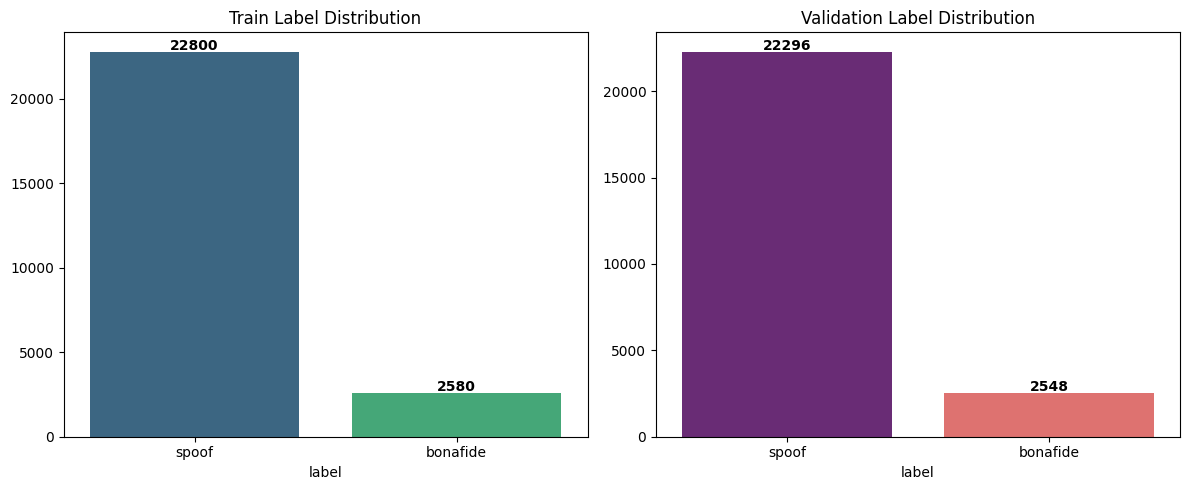

In [16]:
# Plot class distributions
train_counts = train_df['label'].value_counts()
dev_counts   = dev_df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0],
            hue=train_counts.index, palette='viridis', legend=False)
axes[0].set_title("Train Label Distribution")
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 100, f"{v}", ha='center', fontweight='bold')

sns.barplot(x=dev_counts.index, y=dev_counts.values, ax=axes[1],
            hue=dev_counts.index, palette='magma', legend=False)
axes[1].set_title("Validation Label Distribution")
for i, v in enumerate(dev_counts.values):
    axes[1].text(i, v + 100, f"{v}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "class_distribution.png"), dpi=200)
plt.show()

In [26]:
# Stratified balanced sampling for training data
np.random.seed(RANDOM_STATE)
train_bonafide = train_df[train_df['label'] == 'bonafide'].sample(TRAIN_BONAFIDE_SIZE, random_state=RANDOM_STATE)
train_spoof    = train_df[train_df['label'] == 'spoof'].sample(TRAIN_SPOOF_SIZE,       random_state=RANDOM_STATE)
train_subset   = pd.concat([train_bonafide, train_spoof]).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

# Stratified balanced sampling for validation and test data from dev_df
dev_bonafide_all = dev_df[dev_df['label'] == 'bonafide']
dev_spoof_all    = dev_df[dev_df['label'] == 'spoof']

# Validation subset (250 bonafide + 250 spoof)
val_bonafide = dev_bonafide_all.sample(VAL_BONAFIDE_SIZE // 2, random_state=RANDOM_STATE)
val_spoof    = dev_spoof_all.sample(VAL_SPOOF_SIZE // 2,       random_state=RANDOM_STATE)
val_subset   = pd.concat([val_bonafide, val_spoof]).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

# Test subset (remaining 250 bonafide + 250 spoof, held out until final evaluation)
test_bonafide = dev_bonafide_all.drop(val_bonafide.index).sample(VAL_BONAFIDE_SIZE // 2, random_state=RANDOM_STATE)
test_spoof    = dev_spoof_all.drop(val_spoof.index).sample(VAL_SPOOF_SIZE // 2,          random_state=RANDOM_STATE)
test_subset   = pd.concat([test_bonafide, test_spoof]).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)


In [34]:

# Save metadata CSVs
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
train_subset.to_csv(os.path.join(OUTPUT_DIR, "train_subset_metadata.csv"), index=False)
val_subset.to_csv(os.path.join(OUTPUT_DIR,   "val_subset_metadata.csv"),   index=False)

print(f"\n✅ Balanced subsets created & saved.")
print(f"   Train : {len(train_subset)} samples ({TRAIN_BONAFIDE_SIZE} bonafide + {TRAIN_SPOOF_SIZE} spoof)")
print(f"   Val   : {len(val_subset)} samples ({VAL_BONAFIDE_SIZE} bonafide + {VAL_SPOOF_SIZE} spoof)")



✅ Balanced subsets created & saved.
   Train : 3000 samples (1500 bonafide + 1500 spoof)
   Val   : 500 samples (500 bonafide + 500 spoof)


#### EDA: Waveform & Spectrogram Visualisation

In [ ]:
def plot_waveform_and_spectrogram(file_path, label, save_name):
    """Plots raw waveform, preprocessed waveform, and Mel spectrogram."""
    y_raw, _  = librosa.load(file_path, sr=SAMPLE_RATE)
    y_proc    = preprocess_audio(file_path)

    fig, axes = plt.subplots(3, 1, figsize=(10, 10))

    # Raw waveform
    librosa.display.waveshow(y_raw,  sr=SAMPLE_RATE, ax=axes[0], color='royalblue', alpha=0.7)
    axes[0].set_title(f"Raw Waveform — {label}  [{os.path.basename(file_path)}]")
    axes[0].set_ylabel("Amplitude")

    # Preprocessed waveform
    librosa.display.waveshow(y_proc, sr=SAMPLE_RATE, ax=axes[1], color='seagreen', alpha=0.7)
    axes[1].set_title("Preprocessed Waveform (Pre-emphasis + Trim + Normalise)")
    axes[1].set_ylabel("Amplitude")

    # Mel spectrogram
    S    = librosa.feature.melspectrogram(y=y_proc, sr=SAMPLE_RATE,
                                           n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img  = librosa.display.specshow(S_dB, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                                    x_axis='time', y_axis='mel',
                                    ax=axes[2], cmap='viridis')
    axes[2].set_title("Mel Spectrogram (Preprocessed)")
    fig.colorbar(img, ax=axes[2], format='%+2.0f dB')

    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{save_name}.png"), dpi=200)
    plt.show()



─── Genuine (Bonafide) Audio ───


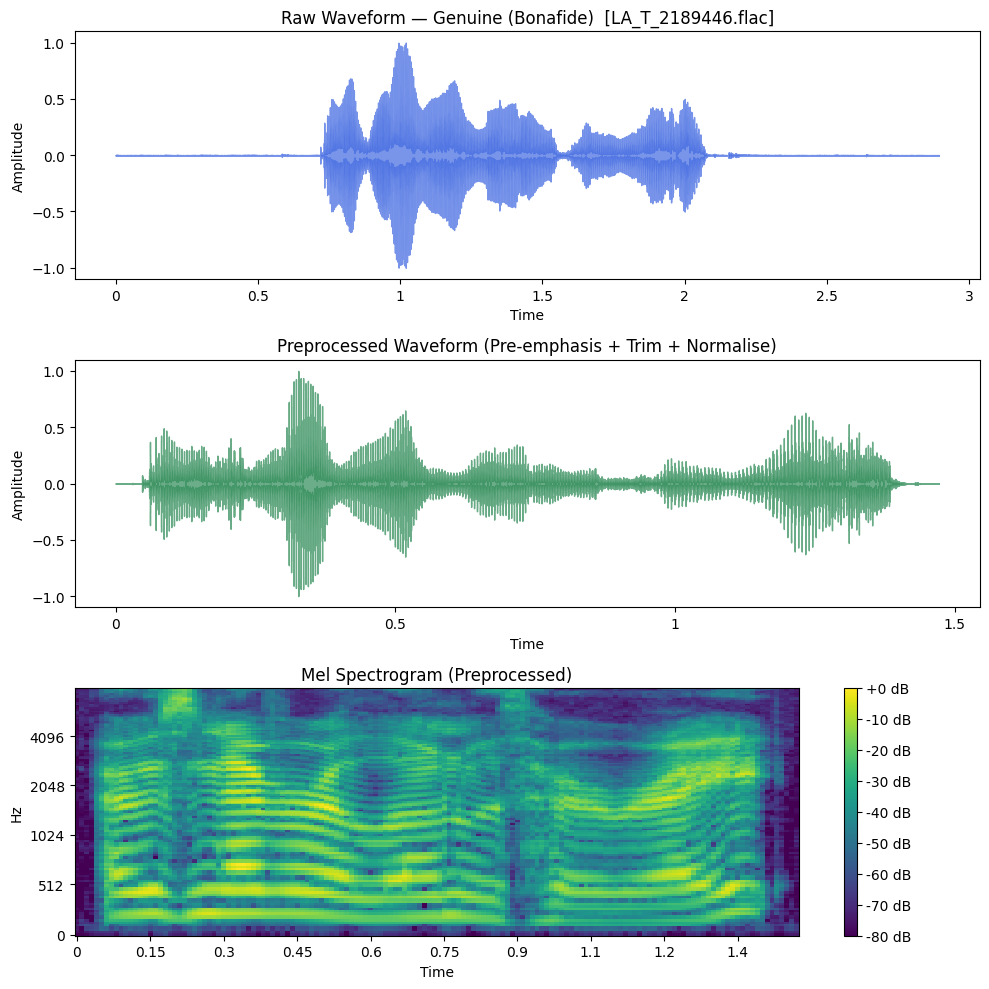

In [ ]:
# Pick one sample of each class from train subset
b_row  = train_subset[train_subset['label'] == 'bonafide'].iloc[0]
b_path = get_audio_path(b_row['file_id'], 'train')
print("─── Genuine (Bonafide) Audio ───")
plot_waveform_and_spectrogram(b_path, "Genuine (Bonafide)", "sample_bonafide_signal")

─── Deepfake (Spoof) Audio ───


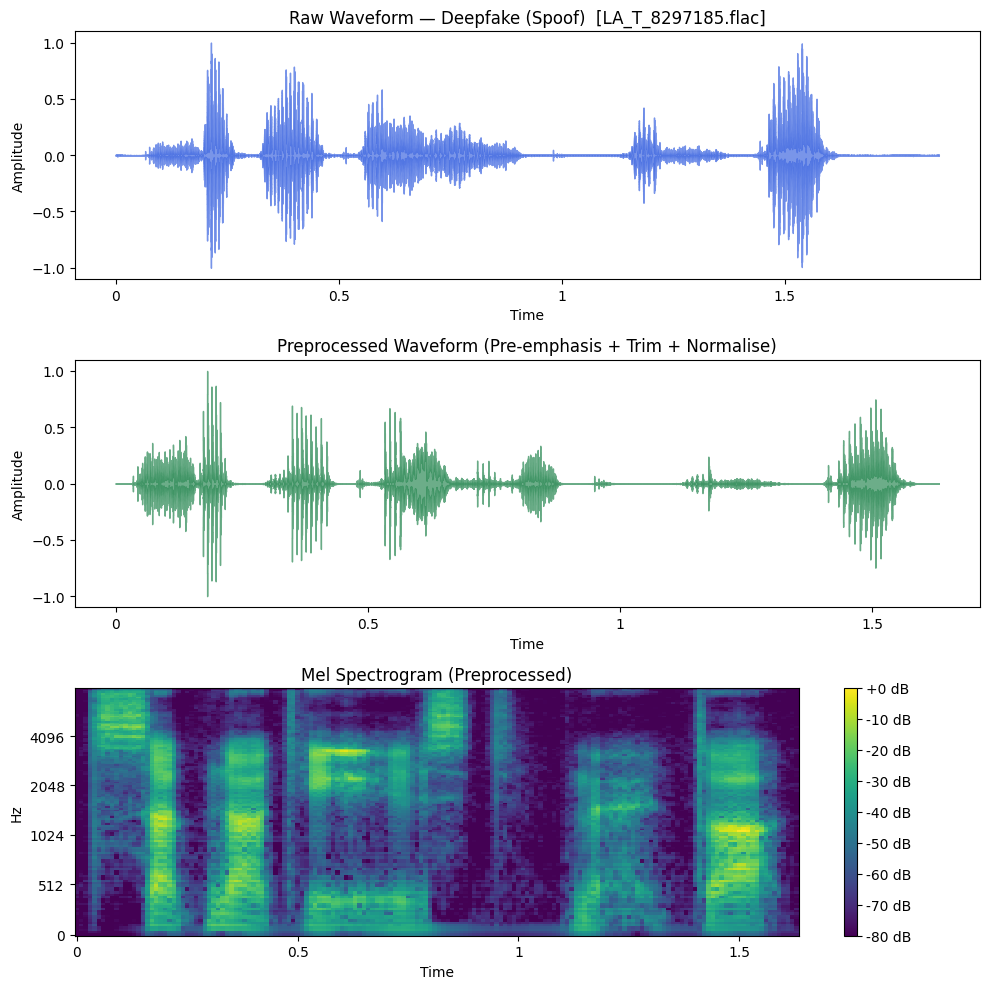

In [ ]:
# Pick one sample of each class from train subset
s_row  = train_subset[train_subset['label'] == 'spoof'].iloc[0]
s_path = get_audio_path(s_row['file_id'], 'train')
print("─── Deepfake (Spoof) Audio ───")
plot_waveform_and_spectrogram(s_path, "Deepfake (Spoof)", "sample_spoof_signal")

#### Feature Extraction (1D MFCC)

In [ ]:
print("=" * 60)
print("Extracting 1D MFCC features for TRAIN subset...")
print("=" * 60)
X_train_raw, y_train = extract_subset_features_1d(train_subset, 'train')

print("\n" + "=" * 60)
print("Extracting 1D MFCC features for VALIDATION subset...")
print("=" * 60)
X_val_raw, y_val = extract_subset_features_1d(val_subset, 'dev')

# StandardScaler — fit on train only, transform both
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)

print(f"\nFeature shapes → Train: {X_train.shape} | Val: {X_val.shape}")

# Save features and scaler
np.save(os.path.join(FEATURE_DIR, "X_train_scaled.npy"), X_train)
np.save(os.path.join(FEATURE_DIR, "y_train.npy"),        y_train)
np.save(os.path.join(FEATURE_DIR, "X_val_scaled.npy"),   X_val)
np.save(os.path.join(FEATURE_DIR, "y_val.npy"),          y_val)
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))

print("✅ Features and scaler saved to disk.")


Extracting 1D MFCC features for TRAIN subset...
  Processed 500/3000 files...
  Processed 1000/3000 files...
  Processed 1500/3000 files...
  Processed 2000/3000 files...
  Processed 2500/3000 files...
  Processed 3000/3000 files...
  ✅ 'train' extraction done in 23.94s | Shape: (3000, 80)

Extracting 1D MFCC features for VALIDATION subset...
  Processed 500/1000 files...
  Processed 1000/1000 files...
  ✅ 'dev' extraction done in 11.06s | Shape: (1000, 80)

Feature shapes → Train: (3000, 80) | Val: (1000, 80)
✅ Features and scaler saved to disk.


#### Model Training & Hyperparameter Tuning

In [ ]:
# ── 1. Baseline RF (300 trees, default depth) ─────────────────────────────
print("=" * 60)
print("Step 6a: Training Baseline Random Forest")
print("=" * 60)
rf_base = get_rf_model(n_estimators=300)
train_rf_model(rf_base, X_train, y_train, model_name="rf_model")
print(f"  OOB Score (Baseline): {rf_base.oob_score_:.4f}")

# ── 2. Grid Search Tuning ─────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Step 6b: Grid Search Hyperparameter Tuning")
print("=" * 60)
grid_search = get_rf_grid_search()
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print(f"\n  Best Parameters : {grid_search.best_params_}")
print(f"  Best CV ROC-AUC : {grid_search.best_score_:.4f}")

joblib.dump(best_rf, os.path.join(MODEL_DIR, "best_rf_model.pkl"))
print(f"\n✅ Tuned RF model saved.")


Step 6a: Training Baseline Random Forest
Fitting rf_model...
  Trained in 15.02s
  Saved → /content/project_outputs/models/rf_model.pkl
  OOB Score (Baseline): 0.9320

Step 6b: Grid Search Hyperparameter Tuning
Fitting 3 folds for each of 12 candidates, totalling 36 fits

  Best Parameters : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
  Best CV ROC-AUC : 0.9802

✅ Tuned RF model saved.


####  Evaluation & Results

In [ ]:
print("=" * 60)
print("Step 7: Evaluating Baseline & Tuned Random Forest")
print("=" * 60)

# Get predictions — assign once, reuse
prob_base  = rf_base.predict_proba(X_val)[:, 1]
prob_tuned = best_rf.predict_proba(X_val)[:, 1]

# Evaluate both models
metrics_base  = evaluate_model_performance(y_val, prob_base,  prob_base,  "Baseline RF")
metrics_tuned = evaluate_model_performance(y_val, prob_tuned, prob_tuned, "Tuned RF")

print("\n── Baseline Random Forest ──")
for k, v in metrics_base.items():  print(f"  {k:20s}: {v}")

print("\n── Tuned Random Forest ──")
for k, v in metrics_tuned.items(): print(f"  {k:20s}: {v}")


Step 7: Evaluating Baseline & Tuned Random Forest

── Baseline Random Forest ──
  Model               : Baseline RF
  TP                  : 415
  TN                  : 404
  FP                  : 96
  FN                  : 85
  Accuracy            : 0.819
  Precision           : 0.8121
  Recall              : 0.83
  F1-Score            : 0.821
  ROC-AUC             : 0.9055
  EER                 : 0.18
  EER-Threshold       : 0.5033

── Tuned Random Forest ──
  Model               : Tuned RF
  TP                  : 403
  TN                  : 412
  FP                  : 88
  FN                  : 97
  Accuracy            : 0.815
  Precision           : 0.8208
  Recall              : 0.806
  F1-Score            : 0.8133
  ROC-AUC             : 0.9052
  EER                 : 0.188
  EER-Threshold       : 0.4937


In [ ]:
# Save CSVs
save_metrics_to_csv(metrics_base,  "baseline_model_evaluation_metrics.csv")
save_metrics_to_csv(metrics_tuned, "best_model_evaluation_metrics.csv")

  Saved → /content/project_outputs/reports/baseline_model_evaluation_metrics.csv
  Saved → /content/project_outputs/reports/best_model_evaluation_metrics.csv


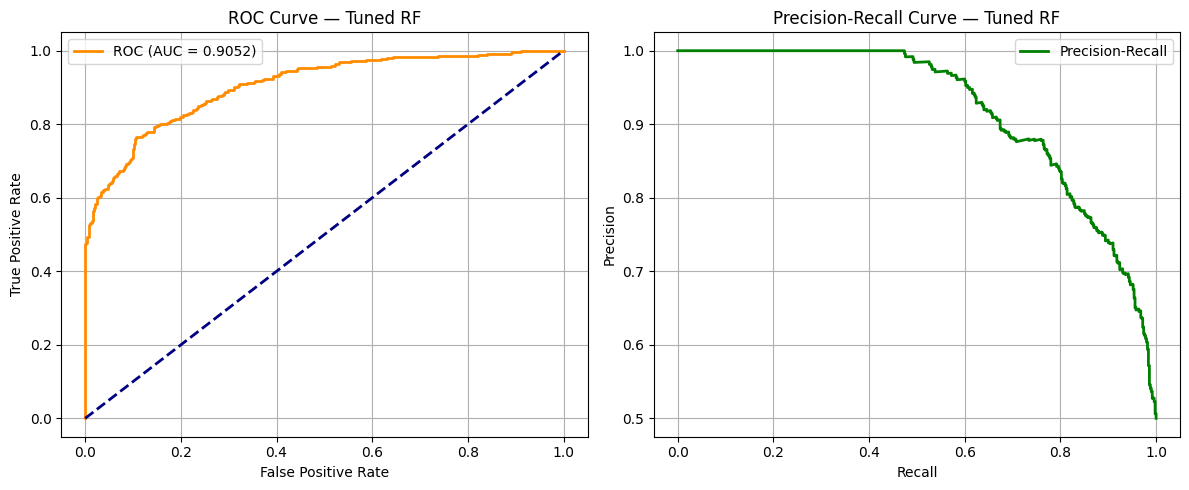

In [ ]:
# ── ROC & Precision-Recall curves ─────────────────────────────────────────
fpr,  tpr,  _ = roc_curve(y_val, prob_tuned)
prec, rec,  _ = precision_recall_curve(y_val, prob_tuned)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f"ROC (AUC = {metrics_tuned['ROC-AUC']:.4f})")
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title("ROC Curve — Tuned RF")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(rec, prec, color='green', lw=2, label="Precision-Recall")
axes[1].set_title("Precision-Recall Curve — Tuned RF")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "random_forest_evaluation.png"), dpi=200)
plt.show()

In [ ]:
# ── Sync outputs to Drive ──────────────────────────────────────────────────
drive_out = "/content/drive/MyDrive/Colab Notebooks/project_outputs"
shutil.copytree(OUTPUT_DIR, drive_out, dirs_exist_ok=True)
print(f"\n✅ Phase 1 complete. All outputs saved to:\n   {drive_out}")


✅ Phase 1 complete. All outputs saved to:
   /content/drive/MyDrive/Colab Notebooks/project_outputs


#### PHASE 2

#### Install PyTorch & Deep Learning Imports

In [ ]:
!pip install torch torchvision soundfile --quiet
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# Detect GPU / CPU
def get_device():
    """Returns GPU if available, else CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")
device = get_device()
print(f"✅ Using device: {device}")
print(f"   PyTorch version: {torch.__version__}")

✅ Using device: cuda
   PyTorch version: 2.11.0+cu128


#### Define PyTorch Dataset & 2D Feature Helpers

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 2D MFCC FEATURE EXTRACTION  (for Deep Learning — shape: N_MFCC × Time_Frames)
# ─────────────────────────────────────────────────────────────────────────────

MAX_TIME_FRAMES = 300   # ~3 seconds of audio at the configured hop length

def extract_mfcc_features_2d(y):
    """
    Extracts 2D MFCC spectrogram of shape (N_MFCC, T).
    Used as input to all three deep learning models.
    """
    mfccs = librosa.feature.mfcc(
        y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC, n_fft=N_FFT,
        hop_length=HOP_LENGTH, win_length=WIN_LENGTH, window=WINDOW_TYPE
    )
    return mfccs

def pad_or_truncate_2d(feats, max_len=MAX_TIME_FRAMES):
    """
    Pads (with zeros) or truncates the time axis of a 2D feature map
    to a fixed length.  Input: (N_MFCC, T) → Output: (N_MFCC, max_len)
    """
    n_mfcc, t = feats.shape
    if t < max_len:
        feats = np.pad(feats, ((0, 0), (0, max_len - t)), mode='constant')
    elif t > max_len:
        feats = feats[:, :max_len]
    return feats

def extract_subset_features_2d(subset_df, subset_name, max_len=MAX_TIME_FRAMES):
    """
    Loops over a metadata DataFrame, preprocesses each audio file,
    extracts 2D padded MFCC maps, and returns (X, y) arrays.
    X shape: (N_samples, N_MFCC, max_len)
    """
    X, y = [], []
    start = time.time()
    for i, (idx, row) in enumerate(subset_df.iterrows()):
        file_path = get_audio_path(row['file_id'], subset_name)
        try:
            y_audio = preprocess_audio(file_path)
            feats   = extract_mfcc_features_2d(y_audio)
            feats   = pad_or_truncate_2d(feats, max_len=max_len)
            X.append(feats)
            y.append(row['label_num'])
        except Exception as e:
            print(f"  ⚠️ Skipping {row['file_id']}: {e}")
        if (i + 1) % 500 == 0:
            print(f"  Processed {i+1}/{len(subset_df)} files...")
    print(f"  ✅ '{subset_name}' 2D extraction done in {time.time()-start:.2f}s")
    return np.array(X), np.array(y)



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PYTORCH DATASET WRAPPER
# ─────────────────────────────────────────────────────────────────────────────

class ASVspoof2019Dataset2D(Dataset):
    """
    PyTorch Dataset for 2D MFCC spectrograms.
    Adds a channel dimension: (N_MFCC, T) → (1, N_MFCC, T)
    Returns: (feature_tensor, label_int)
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        if len(self.X.shape) == 3:           # add channel dim
            self.X = self.X.unsqueeze(1)     # (N, N_MFCC, T) → (N, 1, N_MFCC, T)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

print("✅ 2D feature helpers & PyTorch Dataset class defined.")

✅ 2D feature helpers & PyTorch Dataset class defined.


#### Define All Three Deep Learning Model Architectures

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1 — CNN + BiLSTM  (Phase 2)
# ─────────────────────────────────────────────────────────────────────────────
class CNNBiLSTM(nn.Module):
    """
    Hybrid CNN + Bidirectional LSTM model.
    Three CNN blocks downsample the frequency axis, then a BiLSTM
    captures temporal context. Global average pooling + FC classifies.
    Input: (batch, 1, N_MFCC=40, T=300)
    """
    def __init__(self, n_mfcc=40, time_frames=300, num_classes=2):
        super(CNNBiLSTM, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1,  16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2, 2)          # (40, T)  → (20, T/2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2)          # (20, T/2) → (10, T/4)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2)          # (10, T/4) → (5, T/8)
        )
        freq_reduced      = n_mfcc // 8          # 40 // 8 = 5
        lstm_input_size   = 64 * freq_reduced    # 64 × 5 = 320
        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=128, num_layers=2,
            batch_first=True, bidirectional=True, dropout=0.3
        )
        self.fc_block = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)                  # (B, 64, 5, T/8)
        B, C, F, T = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()  # (B, T, C, F)
        x = x.view(B, T, C * F)                 # (B, T, lstm_input_size)
        lstm_out, _ = self.lstm(x)               # (B, T, 256)
        out = torch.mean(lstm_out, dim=1)        # (B, 256) — global avg pool
        return self.fc_block(out)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2 — ResNet18  (Phase 3)
# ─────────────────────────────────────────────────────────────────────────────
import torchvision.models as tv_models
class ResNet18(nn.Module):
    """
    Standard ResNet18 adapted for single-channel 2D MFCC spectrograms.
    - First conv layer modified: in_channels 3 → 1
    - Final FC layer modified: out_features → num_classes
    Trained from scratch (no pretrained weights).
    Input: (batch, 1, N_MFCC, T)
    """
    def __init__(self, num_classes=2):
        super(ResNet18, self).__init__()
        self.model = tv_models.resnet18(weights=None)
        # Adapt first conv for single-channel input
        orig = self.model.conv1
        self.model.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=orig.out_channels,
            kernel_size=orig.kernel_size,
            stride=orig.stride,
            padding=orig.padding,
            bias=orig.bias
        )
        # Adapt output head
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
    def forward(self, x):
        return self.model(x)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3 — Light CNN (LCNN) with Max-Feature-Map activation  (Phase 4)
# ─────────────────────────────────────────────────────────────────────────────
class MFM(nn.Module):
    """
    Max-Feature-Map (MFM) activation.
    Splits channel dimension in half and takes element-wise maximum.
    Reduces channels by 50%: 2C → C.
    """
    def __init__(self, dim=1):
        super(MFM, self).__init__()
        self.dim = dim
    def forward(self, x):
        size = x.size(self.dim)
        assert size % 2 == 0, f"MFM requires even channel count, got {size}"
        x1, x2 = torch.split(x, size // 2, dim=self.dim)
        return torch.max(x1, x2)
class LCNN(nn.Module):
    """
    Light CNN with Max-Feature-Map activations.
    Four Conv+MFM+Pool blocks progressively compress spatial dims,
    followed by two MFM-gated FC layers.
    Input: (batch, 1, N_MFCC=40, T=300)
    """
    def __init__(self, n_mfcc=40, time_frames=300, num_classes=2):
        super(LCNN, self).__init__()
        # Block 1: Conv(1→16) + MFM(16→8) + Pool
        self.conv1 = nn.Conv2d(1,  16, kernel_size=5, padding=2)
        self.mfm1  = MFM(dim=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        # Block 2: Conv(8→32) + MFM(32→16) + BN + Pool
        self.conv2 = nn.Conv2d(8,  32, kernel_size=3, padding=1)
        self.mfm2  = MFM(dim=1)
        self.bn2   = nn.BatchNorm2d(16)
        self.pool2 = nn.MaxPool2d(2, 2)
        # Block 3: Conv(16→64) + MFM(64→32) + Pool
        self.conv3 = nn.Conv2d(16, 64, kernel_size=3, padding=1)
        self.mfm3  = MFM(dim=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        # Block 4: Conv(32→128) + MFM(128→64) + BN + Pool
        self.conv4 = nn.Conv2d(32, 128, kernel_size=3, padding=1)
        self.mfm4  = MFM(dim=1)
        self.bn4   = nn.BatchNorm2d(64)
        self.pool4 = nn.MaxPool2d(2, 2)
        # Dynamically compute flattened size
        self.flat_features = self._get_flat_size(n_mfcc, time_frames)
        # FC layers with MFM gating
        self.fc1     = nn.Linear(self.flat_features, 128)
        self.mfm_fc1 = MFM(dim=1)
        self.fc2     = nn.Linear(64, num_classes)
    def _get_flat_size(self, n_mfcc, time_frames):
        with torch.no_grad():
            x = torch.zeros(1, 1, n_mfcc, time_frames)
            x = self.pool1(self.mfm1(self.conv1(x)))
            x = self.pool2(self.bn2(self.mfm2(self.conv2(x))))
            x = self.pool3(self.mfm3(self.conv3(x)))
            x = self.pool4(self.bn4(self.mfm4(self.conv4(x))))
            return x.numel()
    def forward(self, x):
        x = self.pool1(self.mfm1(self.conv1(x)))
        x = self.pool2(self.bn2(self.mfm2(self.conv2(x))))
        x = self.pool3(self.mfm3(self.conv3(x)))
        x = self.pool4(self.bn4(self.mfm4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.mfm_fc1(self.fc1(x))
        return self.fc2(x)

In [ ]:
print("✅ All three DL model architectures defined: CNNBiLSTM | ResNet18 | LCNN")

✅ All three DL model architectures defined: CNNBiLSTM | ResNet18 | LCNN


####  PyTorch Training Loop Helper

In [ ]:
def train_pytorch_model(model, train_loader, val_loader, criterion,
                         optimizer, epochs, device, model_name="model"):
    """
    General-purpose PyTorch training loop with:
      - Per-epoch train/val loss & accuracy logging
      - Early stopping (patience = 5 epochs)
      - Best checkpoint saving to MODEL_DIR
    Returns: (best_model, history_dict)
    """
    print(f"\n{'='*60}")
    print(f"Training: {model_name.upper()}  |  Device: {device}")
    print(f"{'='*60}")
    model.to(device)

    history       = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_ctr  = 0
    patience      = 5
    ckpt_path     = os.path.join(MODEL_DIR, f"{model_name}.pth")

    for epoch in range(1, epochs + 1):
        # ── Training phase ──────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        t0 = time.time()

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch_x.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        # ── Validation phase ─────────────────────────────────────────────────
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item() * batch_x.size(0)
                correct  += (outputs.argmax(dim=1) == batch_y).sum().item()
                total    += batch_y.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc   = correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Time: {time.time()-t0:.1f}s")

        # ── Early stopping & checkpointing ───────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_ctr  = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  → Best checkpoint saved (Val Loss: {best_val_loss:.4f})")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stopping at epoch {epoch}. Best Val Loss: {best_val_loss:.4f}")
                break

    # Load best weights back into model
    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        print(f"✅ Best weights restored from {ckpt_path}")

    return model, history


def plot_training_history(history, save_path=None):
    """Plots train/val loss and validation accuracy curves side by side."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='royalblue')
    axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='crimson')
    axes[0].set_title('Loss Curves');  axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs, history['val_acc'], label='Val Accuracy', color='seagreen')
    axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
        print(f"  Plot saved → {save_path}")
    plt.show()


def get_pytorch_predictions(model, data_loader, device):
    """
    Runs inference on a DataLoader.
    Returns: (probabilities, logit_scores, true_labels) — all as numpy arrays.
    Score = logit difference log(P_spoof / P_bonafide), used for EER.
    """
    model.eval()
    all_probs, all_scores, all_labels = [], [], []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x   = batch_x.to(device)
            outputs   = model(batch_x)
            probs     = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            scores    = (outputs[:, 1] - outputs[:, 0]).cpu().numpy()
            all_probs.extend(probs)
            all_scores.extend(scores)
            all_labels.extend(batch_y.numpy())

    return np.array(all_probs), np.array(all_scores), np.array(all_labels)

print("✅ Training loop, history plotter & inference helper defined.")


✅ Training loop, history plotter & inference helper defined.


#### Extract 2D Features & Build DataLoaders

In [ ]:
# ── Config constants needed for DL ──────────────────────────────────────────
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 0.0005
WEIGHT_DECAY = 1e-4

# ── Load metadata saved in Phase 1 ──────────────────────────────────────────
train_subset = pd.read_csv(os.path.join(OUTPUT_DIR, "train_subset_metadata.csv"))
val_subset   = pd.read_csv(os.path.join(OUTPUT_DIR, "val_subset_metadata.csv"))
print(f"Loaded metadata — Train: {len(train_subset)} | Val: {len(val_subset)}")

# ── Extract 2D features (or load if already saved) ──────────────────────────
x_train_path = os.path.join(FEATURE_DIR, "X_train_2d.npy")
y_train_path = os.path.join(FEATURE_DIR, "y_train_2d.npy")
x_val_path   = os.path.join(FEATURE_DIR, "X_val_2d.npy")
y_val_path   = os.path.join(FEATURE_DIR, "y_val_2d.npy")

if os.path.exists(x_train_path) and os.path.exists(x_val_path):
    print("Loading pre-extracted 2D MFCC features from disk...")
    X_train_2d = np.load(x_train_path)
    y_train_2d = np.load(y_train_path)
    X_val_2d   = np.load(x_val_path)
    y_val_2d   = np.load(y_val_path)
else:
    print("Extracting 2D MFCC features (this takes a few minutes)...")
    X_train_2d, y_train_2d = extract_subset_features_2d(train_subset, 'train')
    X_val_2d,   y_val_2d   = extract_subset_features_2d(val_subset,   'dev')
    np.save(x_train_path, X_train_2d)
    np.save(y_train_path, y_train_2d)
    np.save(x_val_path,   X_val_2d)
    np.save(y_val_path,   y_val_2d)


Loaded metadata — Train: 3000 | Val: 1000
Extracting 2D MFCC features (this takes a few minutes)...
  Processed 500/3000 files...
  Processed 1000/3000 files...
  Processed 1500/3000 files...
  Processed 2000/3000 files...
  Processed 2500/3000 files...
  Processed 3000/3000 files...
  ✅ 'train' 2D extraction done in 27.38s
  Processed 500/1000 files...
  Processed 1000/1000 files...
  ✅ 'dev' 2D extraction done in 10.57s


In [ ]:
print(f"\n✅ 2D Feature shapes:")
print(f"   X_train_2d : {X_train_2d.shape}  |  y_train_2d : {y_train_2d.shape}")
print(f"   X_val_2d   : {X_val_2d.shape}    |  y_val_2d   : {y_val_2d.shape}")



✅ 2D Feature shapes:
   X_train_2d : (3000, 40, 300)  |  y_train_2d : (3000,)
   X_val_2d   : (1000, 40, 300)    |  y_val_2d   : (1000,)


In [ ]:
# ── Build PyTorch DataLoaders ────────────────────────────────────────────────
train_dataset = ASVspoof2019Dataset2D(X_train_2d, y_train_2d)
val_dataset   = ASVspoof2019Dataset2D(X_val_2d,   y_val_2d)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
print(f"\n✅ DataLoaders ready.")
print(f"   Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"   Sample batch shape: {next(iter(train_loader))[0].shape}")


✅ DataLoaders ready.
   Train batches: 94 | Val batches: 32
   Sample batch shape: torch.Size([32, 1, 40, 300])


#### Phase 2: Train CNN + BiLSTM

PHASE 2 — CNN + BiLSTM

Training: CNN_BILSTM  |  Device: cuda
Epoch 01/20 | Train Loss: 0.6394 | Val Loss: 0.5608 | Val Acc: 0.7060 | Time: 2.8s
  → Best checkpoint saved (Val Loss: 0.5608)
Epoch 02/20 | Train Loss: 0.4854 | Val Loss: 0.4946 | Val Acc: 0.7580 | Time: 1.2s
  → Best checkpoint saved (Val Loss: 0.4946)
Epoch 03/20 | Train Loss: 0.3584 | Val Loss: 1.0530 | Val Acc: 0.5800 | Time: 1.2s
Epoch 04/20 | Train Loss: 0.3103 | Val Loss: 0.5002 | Val Acc: 0.8050 | Time: 1.2s
Epoch 05/20 | Train Loss: 0.2501 | Val Loss: 0.5139 | Val Acc: 0.8050 | Time: 1.2s
Epoch 06/20 | Train Loss: 0.2108 | Val Loss: 0.8735 | Val Acc: 0.7190 | Time: 1.3s
Epoch 07/20 | Train Loss: 0.1429 | Val Loss: 0.2815 | Val Acc: 0.8800 | Time: 1.3s
  → Best checkpoint saved (Val Loss: 0.2815)
Epoch 08/20 | Train Loss: 0.1436 | Val Loss: 1.2796 | Val Acc: 0.6630 | Time: 1.3s
Epoch 09/20 | Train Loss: 0.1294 | Val Loss: 0.2927 | Val Acc: 0.9040 | Time: 1.3s
Epoch 10/20 | Train Loss: 0.1399 | Val Loss: 1.9285 | Va

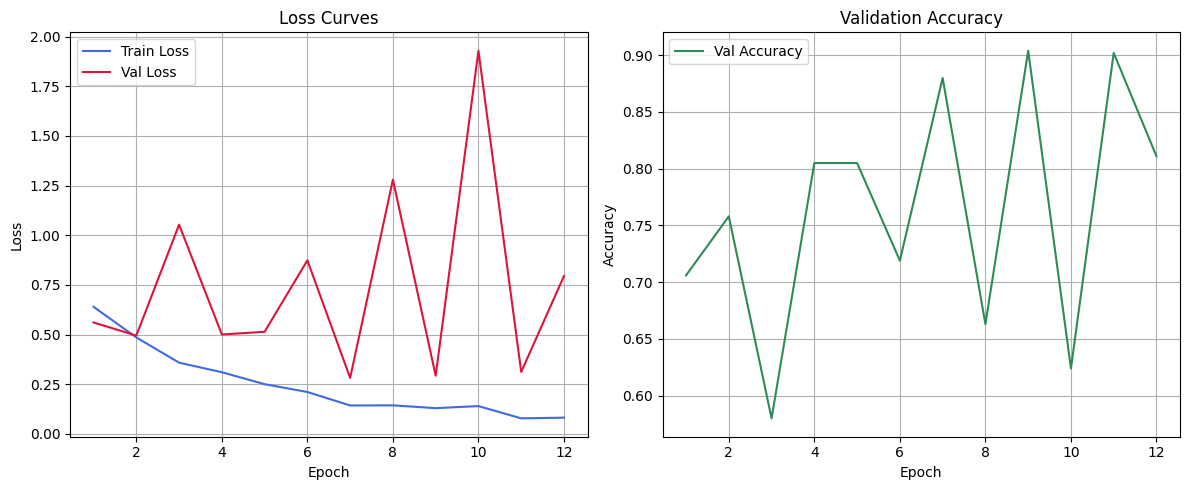

In [ ]:
print("=" * 60)
print("PHASE 2 — CNN + BiLSTM")
print("=" * 60)

cnn_bilstm   = CNNBiLSTM(n_mfcc=N_MFCC, time_frames=MAX_TIME_FRAMES, num_classes=2)
criterion    = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(cnn_bilstm.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

cnn_bilstm, cnn_history = train_pytorch_model(
    cnn_bilstm, train_loader, val_loader,
    criterion, optimizer_cnn,
    epochs=EPOCHS, device=device, model_name="cnn_bilstm"
)

plot_training_history(cnn_history,
                      save_path=os.path.join(PLOT_DIR, "cnn_bilstm_training.png"))

#### Train ResNet18

PHASE 3 — ResNet18

Training: RESNET18  |  Device: cuda
Epoch 01/20 | Train Loss: 0.4636 | Val Loss: 0.8309 | Val Acc: 0.7920 | Time: 3.9s
  → Best checkpoint saved (Val Loss: 0.8309)
Epoch 02/20 | Train Loss: 0.1895 | Val Loss: 0.3969 | Val Acc: 0.8540 | Time: 3.7s
  → Best checkpoint saved (Val Loss: 0.3969)
Epoch 03/20 | Train Loss: 0.1325 | Val Loss: 0.3366 | Val Acc: 0.8640 | Time: 3.7s
  → Best checkpoint saved (Val Loss: 0.3366)
Epoch 04/20 | Train Loss: 0.1064 | Val Loss: 0.3664 | Val Acc: 0.8780 | Time: 3.7s
Epoch 05/20 | Train Loss: 0.0919 | Val Loss: 0.6530 | Val Acc: 0.8060 | Time: 3.7s
Epoch 06/20 | Train Loss: 0.0728 | Val Loss: 0.1969 | Val Acc: 0.9280 | Time: 3.8s
  → Best checkpoint saved (Val Loss: 0.1969)
Epoch 07/20 | Train Loss: 0.0806 | Val Loss: 0.3967 | Val Acc: 0.8830 | Time: 3.8s
Epoch 08/20 | Train Loss: 0.0532 | Val Loss: 3.4387 | Val Acc: 0.5740 | Time: 3.8s
Epoch 09/20 | Train Loss: 0.0527 | Val Loss: 0.4537 | Val Acc: 0.8640 | Time: 3.8s
Epoch 10/20 | Tra

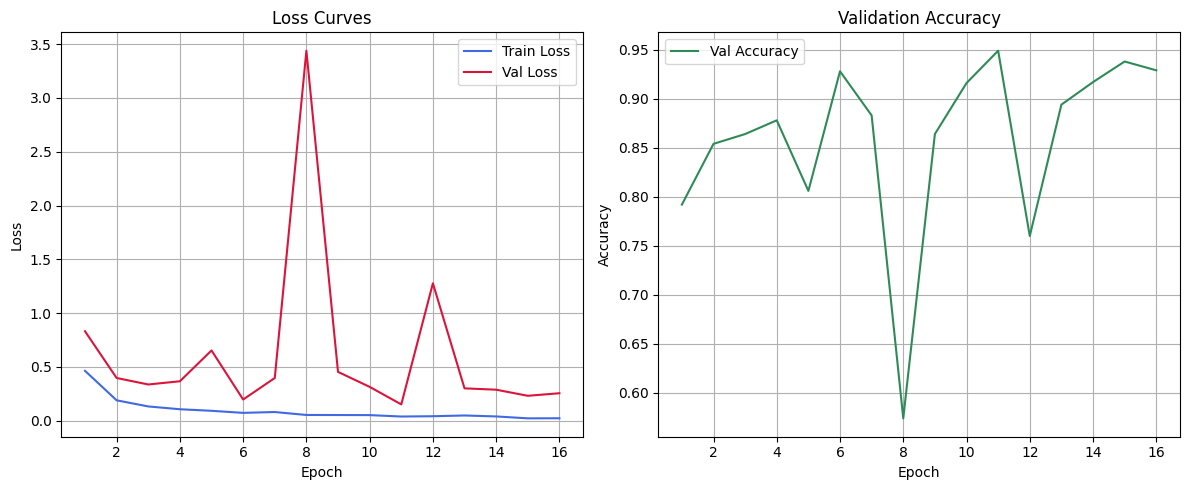

In [ ]:
print("=" * 60)
print("PHASE 3 — ResNet18")
print("=" * 60)

resnet18      = ResNet18(num_classes=2)
optimizer_res = optim.Adam(resnet18.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

resnet18, res_history = train_pytorch_model(
    resnet18, train_loader, val_loader,
    criterion, optimizer_res,
    epochs=EPOCHS, device=device, model_name="resnet18"
)

plot_training_history(res_history,
                      save_path=os.path.join(PLOT_DIR, "resnet18_training.png"))


#### Phase 4: Train LCNN

PHASE 4 — Light CNN (LCNN) with Max-Feature-Map

Training: LCNN  |  Device: cuda
Epoch 01/20 | Train Loss: 0.7699 | Val Loss: 0.6778 | Val Acc: 0.6340 | Time: 1.3s
  → Best checkpoint saved (Val Loss: 0.6778)
Epoch 02/20 | Train Loss: 0.5104 | Val Loss: 0.4950 | Val Acc: 0.7550 | Time: 0.9s
  → Best checkpoint saved (Val Loss: 0.4950)
Epoch 03/20 | Train Loss: 0.3412 | Val Loss: 0.4685 | Val Acc: 0.7840 | Time: 0.9s
  → Best checkpoint saved (Val Loss: 0.4685)
Epoch 04/20 | Train Loss: 0.2369 | Val Loss: 0.3915 | Val Acc: 0.8420 | Time: 0.9s
  → Best checkpoint saved (Val Loss: 0.3915)
Epoch 05/20 | Train Loss: 0.1779 | Val Loss: 0.3336 | Val Acc: 0.8730 | Time: 0.9s
  → Best checkpoint saved (Val Loss: 0.3336)
Epoch 06/20 | Train Loss: 0.1305 | Val Loss: 0.2857 | Val Acc: 0.8820 | Time: 0.9s
  → Best checkpoint saved (Val Loss: 0.2857)
Epoch 07/20 | Train Loss: 0.1164 | Val Loss: 0.7831 | Val Acc: 0.7570 | Time: 0.9s
Epoch 08/20 | Train Loss: 0.0992 | Val Loss: 0.5227 | Val Acc: 0.831

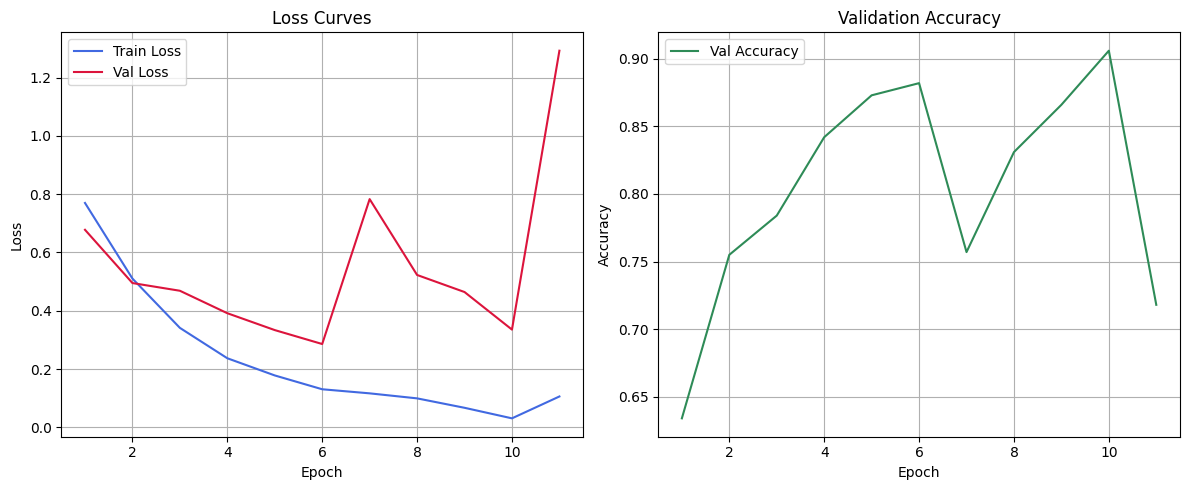

In [ ]:
print("=" * 60)
print("PHASE 4 — Light CNN (LCNN) with Max-Feature-Map")
print("=" * 60)

lcnn           = LCNN(n_mfcc=N_MFCC, time_frames=MAX_TIME_FRAMES, num_classes=2)
optimizer_lcnn = optim.Adam(lcnn.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

lcnn, lcnn_history = train_pytorch_model(
    lcnn, train_loader, val_loader,
    criterion, optimizer_lcnn,
    epochs=EPOCHS, device=device, model_name="lcnn"
)

plot_training_history(lcnn_history,
                      save_path=os.path.join(PLOT_DIR, "lcnn_training.png"))


####  Evaluate All Three DL Models & Save Outputs

In [ ]:
print("=" * 60)
print("EVALUATING ALL THREE DEEP LEARNING MODELS")
print("=" * 60)
# ── Get predictions ──────────────────────────────────────────────────────────
prob_cnn,  score_cnn,  _        = get_pytorch_predictions(cnn_bilstm, val_loader, device)
prob_res,  score_res,  _        = get_pytorch_predictions(resnet18,   val_loader, device)
prob_lcnn, score_lcnn, y_val_dl = get_pytorch_predictions(lcnn,       val_loader, device)

# ── Compute metrics ───────────────────────────────────────────────────────────
metrics_cnn  = evaluate_model_performance(y_val_dl, prob_cnn,  score_cnn,  "CNN+BiLSTM")
metrics_res  = evaluate_model_performance(y_val_dl, prob_res,  score_res,  "ResNet18")
metrics_lcnn = evaluate_model_performance(y_val_dl, prob_lcnn, score_lcnn, "LCNN")

print("\n── CNN + BiLSTM ──")
for k, v in metrics_cnn.items():  print(f"  {k:20s}: {v}")

print("\n── ResNet18 ──")
for k, v in metrics_res.items():  print(f"  {k:20s}: {v}")

print("\n── LCNN ──")
for k, v in metrics_lcnn.items(): print(f"  {k:20s}: {v}")


EVALUATING ALL THREE DEEP LEARNING MODELS

── CNN + BiLSTM ──
  Model               : CNN+BiLSTM
  TP                  : 434
  TN                  : 446
  FP                  : 54
  FN                  : 66
  Accuracy            : 0.88
  Precision           : 0.8893
  Recall              : 0.868
  F1-Score            : 0.8785
  ROC-AUC             : 0.9512
  EER                 : 0.126
  EER-Threshold       : -0.2114

── ResNet18 ──
  Model               : ResNet18
  TP                  : 470
  TN                  : 479
  FP                  : 21
  FN                  : 30
  Accuracy            : 0.949
  Precision           : 0.9572
  Recall              : 0.94
  F1-Score            : 0.9485
  ROC-AUC             : 0.9896
  EER                 : 0.054
  EER-Threshold       : -0.4675

── LCNN ──
  Model               : LCNN
  TP                  : 472
  TN                  : 410
  FP                  : 90
  FN                  : 28
  Accuracy            : 0.882
  Precision           : 0

In [ ]:
# ── Save evaluation CSVs ──────────────────────────────────────────────────────
save_metrics_to_csv(metrics_cnn,  "cnn_bilstm_evaluation_metrics.csv")
save_metrics_to_csv(metrics_res,  "resnet18_evaluation_metrics.csv")
save_metrics_to_csv(metrics_lcnn, "lcnn_evaluation_metrics.csv")


  Saved → /content/project_outputs/reports/cnn_bilstm_evaluation_metrics.csv
  Saved → /content/project_outputs/reports/resnet18_evaluation_metrics.csv
  Saved → /content/project_outputs/reports/lcnn_evaluation_metrics.csv


In [ ]:

# ── Sync all outputs to Google Drive ─────────────────────────────────────────
drive_out = "/content/drive/MyDrive/Colab Notebooks/project_outputs"
shutil.copytree(OUTPUT_DIR, drive_out, dirs_exist_ok=True)

print(f"✅ Phases 2–4 complete. All outputs backed up to Drive:\n   {drive_out}")

✅ Phases 2–4 complete. All outputs backed up to Drive:
   /content/drive/MyDrive/Colab Notebooks/project_outputs


####  Phase 5 CONFIDENCE CALIBRATION

#### Calibration Helpers & Calibrator Class

In [ ]:
# ── CELL 5a: CALIBRATION UTILITIES DEFINITIONS ───────────────────────────────

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import os

def compute_ece_and_brier(y_true, y_prob, n_bins=10):
    """
    Computes Expected Calibration Error (ECE) and Brier Score.
    """
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    # Brier Score
    brier = np.mean((y_true - y_prob) ** 2)

    # ECE
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]

        if i == n_bins - 1:
            in_bin = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            in_bin = (y_prob >= bin_lower) & (y_prob < bin_upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)

    return ece, brier


class ModelCalibrator:
    """
    Fits and applies Platt Scaling and Isotonic Regression to a model's outputs.
    """
    def __init__(self):
        self.platt_scaler = LogisticRegression(penalty=None, solver='lbfgs')
        self.isotonic_scaler = IsotonicRegression(out_of_bounds='clip')

    def fit(self, val_scores, val_probs, val_labels):
        """
        Fits both Platt Scaling and Isotonic Regression calibrators.
        """
        self.platt_scaler.fit(val_scores.reshape(-1, 1), val_labels)
        self.isotonic_scaler.fit(val_probs, val_labels)

    def calibrate_platt(self, scores):
        """
        Applies Platt Scaling to convert scores/logits to calibrated probabilities.
        """
        return self.platt_scaler.predict_proba(scores.reshape(-1, 1))[:, 1]

    def calibrate_isotonic(self, probs):
        """
        Applies Isotonic Regression to convert probabilities to calibrated probabilities.
        """
        return self.isotonic_scaler.predict(probs)


In [ ]:
# ── CELL 5b: FIT CALIBRATORS AND GENERATE CALIBRATED PROBABILITIES ────────────

print("Fitting calibrators on validation probabilities...")

# Fit calibration models on validation set
cal_rf = ModelCalibrator()
cal_rf.fit(prob_tuned, prob_tuned, y_val)

cal_cnn = ModelCalibrator()
cal_cnn.fit(score_cnn, prob_cnn, y_val)

cal_res = ModelCalibrator()
cal_res.fit(score_res, prob_res, y_val)

cal_lcnn = ModelCalibrator()
cal_lcnn.fit(score_lcnn, prob_lcnn, y_val)

# Generate calibrated validation probabilities
prob_rf_platt = cal_rf.calibrate_platt(prob_tuned)
prob_rf_iso   = cal_rf.calibrate_isotonic(prob_tuned)

prob_cnn_platt = cal_cnn.calibrate_platt(score_cnn)
prob_cnn_iso   = cal_cnn.calibrate_isotonic(prob_cnn)

prob_res_platt = cal_res.calibrate_platt(score_res)
prob_res_iso   = cal_res.calibrate_isotonic(prob_res)

prob_lcnn_platt = cal_lcnn.calibrate_platt(score_lcnn)
prob_lcnn_iso   = cal_lcnn.calibrate_isotonic(prob_lcnn)

print("✅ Calibrators fit successfully and predictions calibrated.")


Fitting calibrators on validation probabilities...
✅ Calibrators fit successfully and predictions calibrated.


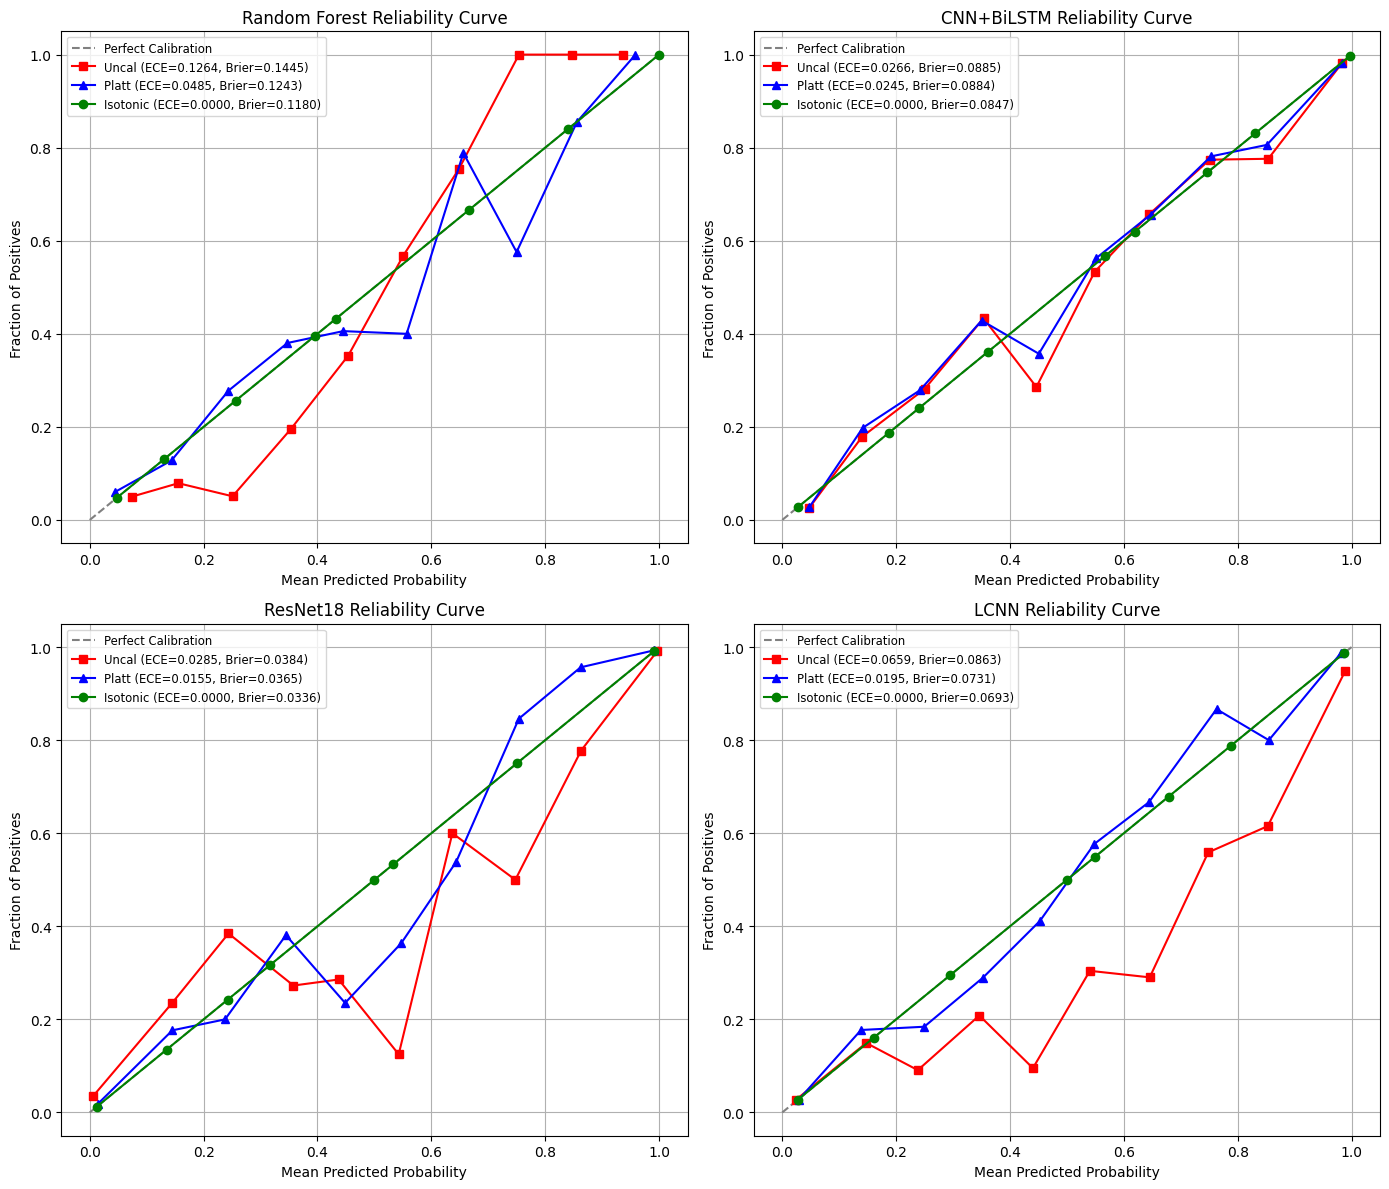

✅ Reliability diagram grid plotted & saved.


In [ ]:
# ── CELL 5c: PLOT RELIABILITY CURVES GRID ────────────────────────────────────

def plot_reliability_diagrams(models_data, save_path=None):
    """
    Plots reliability diagrams for all models in a 2x2 grid.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for idx, (model_name, data) in enumerate(models_data.items()):
        ax = axes[idx]
        y_true = data['y_true']

        # Plot diagonal perfect calibration line
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

        # 1. Uncalibrated
        prob_true_un, prob_pred_un = calibration_curve(y_true, data['prob_uncal'], n_bins=10)
        ece_un, brier_un = compute_ece_and_brier(y_true, data['prob_uncal'])
        ax.plot(prob_pred_un, prob_true_un, marker='s', color='red', label=f'Uncal (ECE={ece_un:.4f}, Brier={brier_un:.4f})')

        # 2. Platt Scaled
        prob_true_pl, prob_pred_pl = calibration_curve(y_true, data['prob_platt'], n_bins=10)
        ece_pl, brier_pl = compute_ece_and_brier(y_true, data['prob_platt'])
        ax.plot(prob_pred_pl, prob_true_pl, marker='^', color='blue', label=f'Platt (ECE={ece_pl:.4f}, Brier={brier_pl:.4f})')

        # 3. Isotonic
        prob_true_is, prob_pred_is = calibration_curve(y_true, data['prob_isotonic'], n_bins=10)
        ece_is, brier_is = compute_ece_and_brier(y_true, data['prob_isotonic'])
        ax.plot(prob_pred_is, prob_true_is, marker='o', color='green', label=f'Isotonic (ECE={ece_is:.4f}, Brier={brier_is:.4f})')

        ax.set_title(f'{model_name} Reliability Curve')
        ax.set_xlabel('Mean Predicted Probability')
        ax.set_ylabel('Fraction of Positives')
        ax.legend(loc='upper left', fontsize='small')
        ax.grid(True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

# Compile metrics and plot
models_cal_data = {
    'Random Forest': {
        'y_true': y_val, 'prob_uncal': prob_tuned, 'prob_platt': prob_rf_platt, 'prob_isotonic': prob_rf_iso
    },
    'CNN+BiLSTM': {
        'y_true': y_val, 'prob_uncal': prob_cnn, 'prob_platt': prob_cnn_platt, 'prob_isotonic': prob_cnn_iso
    },
    'ResNet18': {
        'y_true': y_val, 'prob_uncal': prob_res, 'prob_platt': prob_res_platt, 'prob_isotonic': prob_res_iso
    },
    'LCNN': {
        'y_true': y_val, 'prob_uncal': prob_lcnn, 'prob_platt': prob_lcnn_platt, 'prob_isotonic': prob_lcnn_iso
    }
}

plot_reliability_diagrams(models_cal_data, save_path=os.path.join(PLOT_DIR, "calibration_reliability_diagrams.png"))
print("✅ Reliability diagram grid plotted & saved.")


##### PHASE 6: EXPLAINABLE AI (XAI)

In [ ]:
# ── CELL 6a: RF SHAP FEATURE DEPENDENCY VISUALIZATIONS ───────────────────────

import shap

def generate_rf_shap_explanations(rf_model, X_train, X_val, feature_names=None, save_dir=PLOT_DIR):
    """
    Computes SHAP values and saves beeswarm and waterfall plots for the Random Forest model.
    """
    print("Computing SHAP values for Random Forest model...")
    explainer = shap.TreeExplainer(rf_model)

    # Sample validation set for speed
    np.random.seed(RANDOM_STATE)
    sample_indices = np.random.choice(len(X_val), min(100, len(X_val)), replace=False)
    X_sample = X_val[sample_indices]

    # Compute SHAP values
    shap_values = explainer.shap_values(X_sample)

    # Handle SHAP output structure changes across versions
    if isinstance(shap_values, list):
        class1_shap = shap_values[1]
        base_value = explainer.expected_value[1]
    else:
        if len(shap_values.shape) == 3:
            class1_shap = shap_values[:, :, 1]
            base_value = explainer.expected_value[1]
        else:
            class1_shap = shap_values
            base_value = explainer.expected_value

    # Save Beeswarm plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(class1_shap, X_sample, feature_names=feature_names, show=False)
    plt.title("SHAP Beeswarm Plot (Random Forest - Spoof Class)", fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    beeswarm_path = os.path.join(save_dir, "shap_beeswarm.png")
    plt.savefig(beeswarm_path, dpi=200)
    plt.close()

    # Save Waterfall plot for the first sample in the subset
    plt.figure(figsize=(8, 6))
    single_explanation = shap.Explanation(
        values=class1_shap[0],
        base_values=base_value,
        data=X_sample[0],
        feature_names=feature_names
    )
    shap.plots.waterfall(single_explanation, max_display=10, show=False)
    plt.title("SHAP Waterfall Plot for Single Sample", fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    waterfall_path = os.path.join(save_dir, "shap_waterfall.png")
    plt.savefig(waterfall_path, dpi=200)
    plt.close()

    print(f"SHAP explanations saved: \n  - Beeswarm: {beeswarm_path}\n  - Waterfall: {waterfall_path}")

# Run RF SHAP analysis
feature_names = [f"MFCC_Mean_{i}" for i in range(1, N_MFCC+1)] + [f"MFCC_Std_{i}" for i in range(1, N_MFCC+1)]
generate_rf_shap_explanations(best_rf, X_train, X_val, feature_names=feature_names)


Computing SHAP values for Random Forest model...


/tmp/ipykernel_994/1631496303.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(class1_shap, X_sample, feature_names=feature_names, show=False)


SHAP explanations saved: 
  - Beeswarm: /content/project_outputs/plots/shap_beeswarm.png
  - Waterfall: /content/project_outputs/plots/shap_waterfall.png


/tmp/ipykernel_994/524382110.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(class1_shap, X_sample, feature_names=feature_names, show=False)


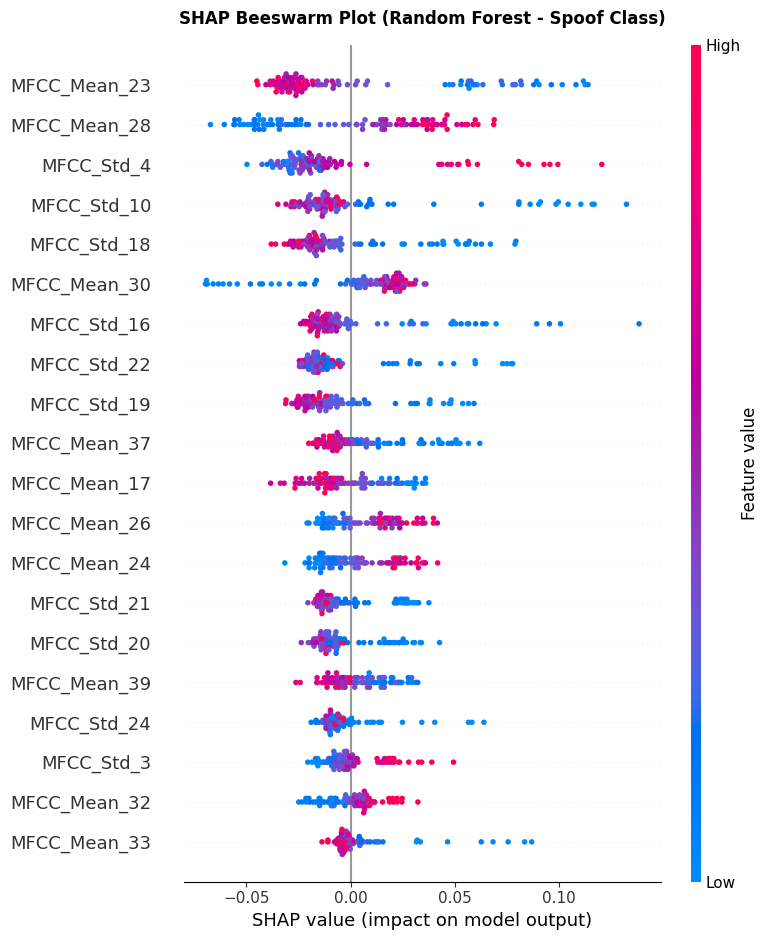

In [ ]:
# ── CELL 6b: RF SHAP BEESWARM PLOT ───────────────────────────────────────────

import shap
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(len(X_val), min(100, len(X_val)), replace=False)
X_sample = X_val[sample_indices]

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    class1_shap = shap_values[1]
else:
    class1_shap = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

feature_names = [f"MFCC_Mean_{i}" for i in range(1, N_MFCC+1)] + [f"MFCC_Std_{i}" for i in range(1, N_MFCC+1)]

plt.figure(figsize=(10, 6))
shap.summary_plot(class1_shap, X_sample, feature_names=feature_names, show=False)
plt.title("SHAP Beeswarm Plot (Random Forest - Spoof Class)", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

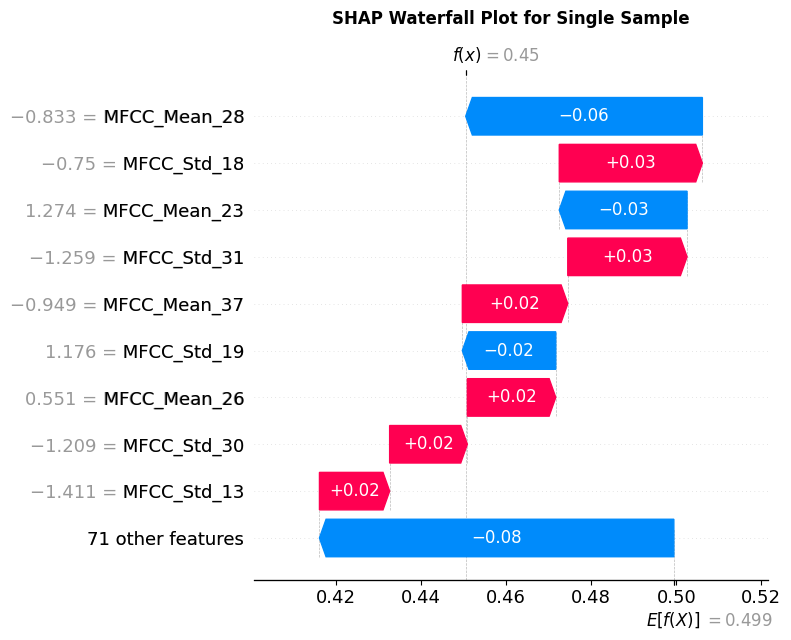

In [ ]:
# ── CELL 6c: RF SHAP WATERFALL PLOT ──────────────────────────────────────────

import shap
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(len(X_val), min(100, len(X_val)), replace=False)
X_sample = X_val[sample_indices]

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    class1_shap = shap_values[1]
    base_value = explainer.expected_value[1]
else:
    if len(shap_values.shape) == 3:
        class1_shap = shap_values[:, :, 1]
        base_value = explainer.expected_value[1]
    else:
        class1_shap = shap_values
        base_value = explainer.expected_value

feature_names = [f"MFCC_Mean_{i}" for i in range(1, N_MFCC+1)] + [f"MFCC_Std_{i}" for i in range(1, N_MFCC+1)]

single_explanation = shap.Explanation(
    values=class1_shap[0],
    base_values=base_value,
    data=X_sample[0],
    feature_names=feature_names
)

plt.figure(figsize=(8, 6))
shap.plots.waterfall(single_explanation, max_display=10, show=False)
plt.title("SHAP Waterfall Plot for Single Sample", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# ── CELL 6c: PYTORCH GRADCAM UTILITIES DEFINITION ─────────────────────────────

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class PyTorchGradCAM:
    """
    Hook-based GradCAM implementation for PyTorch models.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.features = None

        # Register hooks
        self.forward_hook = target_layer.register_forward_hook(self._save_features)
        self.backward_hook = target_layer.register_full_backward_hook(self._save_gradients)

    def _save_features(self, module, input, output):
        self.features = output

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, class_idx=1):
        """
        Generates a GradCAM heatmap normalized to [0, 1].
        """
        # Save current cuDNN state and temporarily disable to allow RNN backward in eval mode
        was_cudnn_enabled = torch.backends.cudnn.enabled
        torch.backends.cudnn.enabled = False

        self.model.eval()
        self.model.zero_grad()

        output = self.model(input_tensor)
        score = output[0, class_idx]
        score.backward()

        # Extract gradients and features
        gradients = self.gradients.cpu().data.numpy()[0]
        features = self.features.cpu().data.numpy()[0]

        # Restore original cuDNN state
        torch.backends.cudnn.enabled = was_cudnn_enabled

        # Compute channel weights (global average pooling of gradients)
        weights = np.mean(gradients, axis=(1, 2))

        # Weighted combination of feature maps
        cam = np.zeros(features.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * features[i]

        cam = np.maximum(cam, 0)

        # Resize cam to original input size
        cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
        cam_resized_tensor = F.interpolate(
            cam_tensor,
            size=(input_tensor.shape[2], input_tensor.shape[3]),
            mode='bilinear',
            align_corners=False
        )
        cam_resized = cam_resized_tensor.squeeze().numpy()

        if np.max(cam_resized) > 0:
            cam_resized = cam_resized / np.max(cam_resized)

        return cam_resized

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()


def plot_gradcam_on_spectrogram(spectrogram, heatmap, title="GradCAM", save_path=None):
    """
    Overlays the GradCAM heatmap on the original MFCC spectrogram.
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # 1. Original Spectrogram
    im0 = axes[0].imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis')
    axes[0].set_title("Original MFCC Spectrogram")
    axes[0].set_ylabel("MFCC Index")
    fig.colorbar(im0, ax=axes[0], format='%+2.0f dB')

    # 2. GradCAM Overlay
    axes[1].imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis')
    im1 = axes[1].imshow(heatmap, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
    axes[1].set_title(f"GradCAM Overlay ({title})")
    axes[1].set_ylabel("MFCC Index")
    axes[1].set_xlabel("Time Frames")
    fig.colorbar(im1, ax=axes[1])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
        print(f"Saved GradCAM plot to {save_path}")
    plt.show()
    plt.close()


In [ ]:
# ── CELL 6d: GENERATE GRADCAM VISUALIZATIONS FOR DL MODELS ────────────────────

# Select a validation sample for deep learning explainability (index 0)
sample_x = torch.tensor(X_val_2d[0]).unsqueeze(0).unsqueeze(0).to(device)  # shape: (1, 1, 40, 300)
spectrogram_np = X_val_2d[0] # shape: (40, 300)

# Setup GradCAM target layers
cam_cnn = PyTorchGradCAM(cnn_bilstm, cnn_bilstm.conv_block3)
cam_res = PyTorchGradCAM(resnet18, resnet18.model.layer4)
cam_lcnn = PyTorchGradCAM(lcnn, lcnn.conv4)

# Generate heatmaps
heatmap_cnn = cam_cnn.generate_heatmap(sample_x)
heatmap_res = cam_res.generate_heatmap(sample_x)
heatmap_lcnn = cam_lcnn.generate_heatmap(sample_x)

# Unregister hooks
cam_cnn.remove_hooks()
cam_res.remove_hooks()
cam_lcnn.remove_hooks()


Saved GradCAM plot to /content/project_outputs/plots/cnn_bilstm_gradcam.png


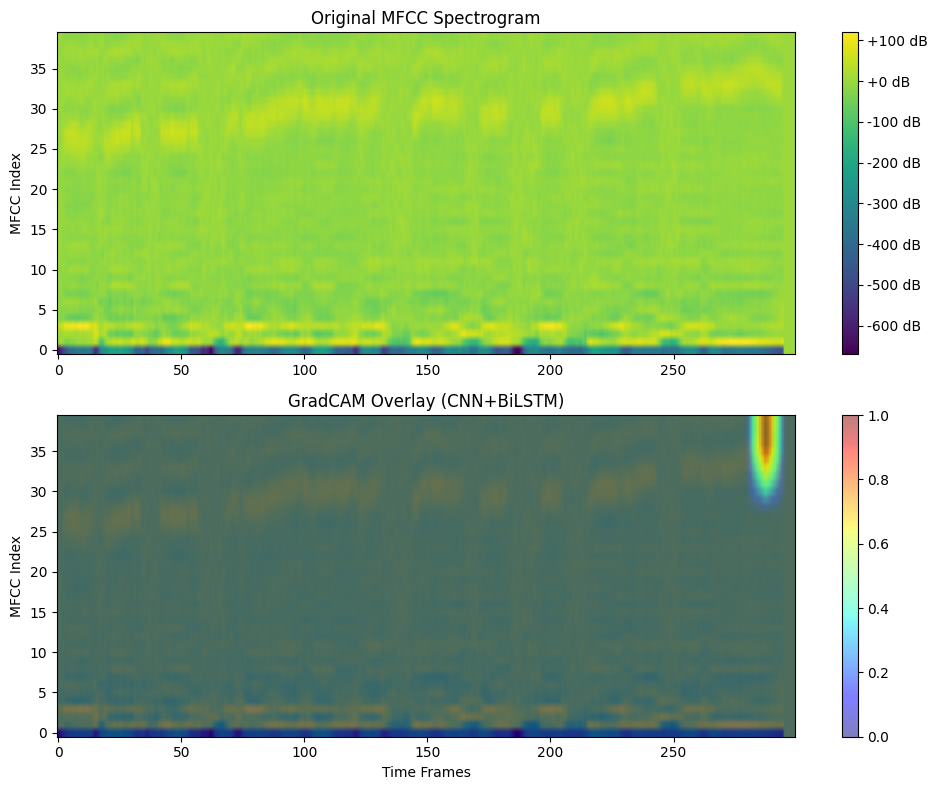

In [ ]:
# Plot overlays & save plots
plot_gradcam_on_spectrogram(spectrogram_np, heatmap_cnn, title="CNN+BiLSTM",
                            save_path=os.path.join(PLOT_DIR, "cnn_bilstm_gradcam.png"))

Saved GradCAM plot to /content/project_outputs/plots/resnet18_gradcam.png


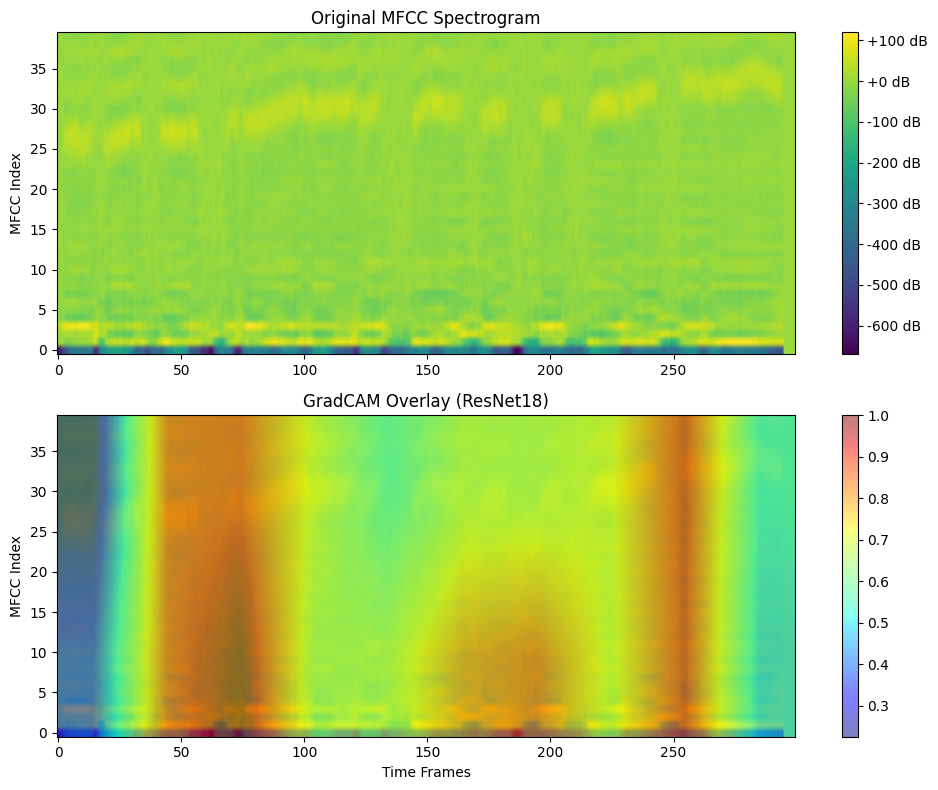

In [ ]:
plot_gradcam_on_spectrogram(spectrogram_np, heatmap_res, title="ResNet18",
                            save_path=os.path.join(PLOT_DIR, "resnet18_gradcam.png"))

Saved GradCAM plot to /content/project_outputs/plots/lcnn_gradcam.png


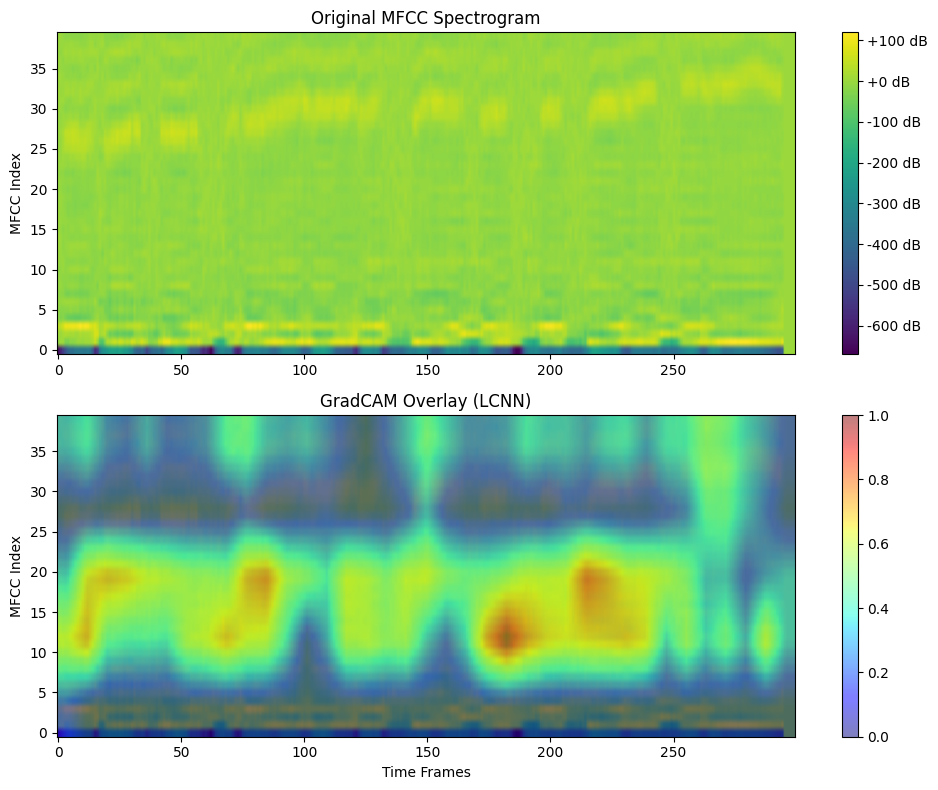

In [ ]:
plot_gradcam_on_spectrogram(spectrogram_np, heatmap_lcnn, title="LCNN",
                            save_path=os.path.join(PLOT_DIR, "lcnn_gradcam.png"))

#### PHASE 7: REPORTING & BACKUP

In [ ]:
# ── CELL 7a: COMPILE METRICS DATAFRAME WITH ECE & BRIER SCORES ───────────────
import pandas as pd

# Calculate calibration metrics (ECE & Brier) for all models
ece_rf, brier_rf = compute_ece_and_brier(y_val, prob_tuned)
ece_rf_pl, brier_rf_pl = compute_ece_and_brier(y_val, prob_rf_platt)
ece_rf_is, brier_rf_is = compute_ece_and_brier(y_val, prob_rf_iso)

ece_cnn, brier_cnn = compute_ece_and_brier(y_val, prob_cnn)
ece_cnn_pl, brier_cnn_pl = compute_ece_and_brier(y_val, prob_cnn_platt)
ece_cnn_is, brier_cnn_is = compute_ece_and_brier(y_val, prob_cnn_iso)

ece_res, brier_res = compute_ece_and_brier(y_val, prob_res)
ece_res_pl, brier_res_pl = compute_ece_and_brier(y_val, prob_res_platt)
ece_res_is, brier_res_is = compute_ece_and_brier(y_val, prob_res_iso)

ece_lcnn, brier_lcnn = compute_ece_and_brier(y_val, prob_lcnn)
ece_lcnn_pl, brier_lcnn_pl = compute_ece_and_brier(y_val, prob_lcnn_platt)
ece_lcnn_is, brier_lcnn_is = compute_ece_and_brier(y_val, prob_lcnn_iso)

In [ ]:
# Compile results dataframe
metrics_compiled = pd.DataFrame([
    {
        "ModelName": "Random Forest", "Acc": metrics_tuned['Accuracy'], "F1": metrics_tuned['F1-Score'], "AUC": metrics_tuned['ROC-AUC'], "EER": metrics_tuned['EER'],
        "ECE": ece_rf, "Brier": brier_rf,
        "ECE_Platt": ece_rf_pl, "Brier_Platt": brier_rf_pl,
        "ECE_Iso": ece_rf_is, "Brier_Iso": brier_rf_is
    },
    {
        "ModelName": "CNN+BiLSTM", "Acc": metrics_cnn['Accuracy'], "F1": metrics_cnn['F1-Score'], "AUC": metrics_cnn['ROC-AUC'], "EER": metrics_cnn['EER'],
        "ECE": ece_cnn, "Brier": brier_cnn,
        "ECE_Platt": ece_cnn_pl, "Brier_Platt": brier_cnn_pl,
        "ECE_Iso": ece_cnn_is, "Brier_Iso": brier_cnn_is
    },
    {
        "ModelName": "ResNet18", "Acc": metrics_res['Accuracy'], "F1": metrics_res['F1-Score'], "AUC": metrics_res['ROC-AUC'], "EER": metrics_res['EER'],
        "ECE": ece_res, "Brier": brier_res,
        "ECE_Platt": ece_res_pl, "Brier_Platt": brier_res_pl,
        "ECE_Iso": ece_res_is, "Brier_Iso": brier_res_is
    },
    {
        "ModelName": "LCNN", "Acc": metrics_lcnn['Accuracy'], "F1": metrics_lcnn['F1-Score'], "AUC": metrics_lcnn['ROC-AUC'], "EER": metrics_lcnn['EER'],
        "ECE": ece_lcnn, "Brier": brier_lcnn,
        "ECE_Platt": ece_lcnn_pl, "Brier_Platt": brier_lcnn_pl,
        "ECE_Iso": ece_lcnn_is, "Brier_Iso": brier_lcnn_is
    }
])

In [ ]:
metrics_compiled.to_csv(os.path.join(REPORT_DIR, "compiled_comparative_report.csv"), index=False)
print("Compiled comparative metrics:")
print(metrics_compiled.to_string(index=False))

Compiled comparative metrics:
    ModelName   Acc     F1    AUC   EER      ECE    Brier  ECE_Platt  Brier_Platt      ECE_Iso  Brier_Iso
Random Forest 0.815 0.8133 0.9052 0.188 0.126412 0.144487   0.048517     0.124335 4.424239e-17   0.117975
   CNN+BiLSTM 0.880 0.8785 0.9512 0.126 0.026587 0.088483   0.024492     0.088414 1.211464e-08   0.084709
     ResNet18 0.949 0.9485 0.9896 0.054 0.028535 0.038369   0.015530     0.036503 3.820825e-07   0.033603
         LCNN 0.882 0.8889 0.9635 0.096 0.065917 0.086265   0.019455     0.073079 2.001226e-08   0.069314


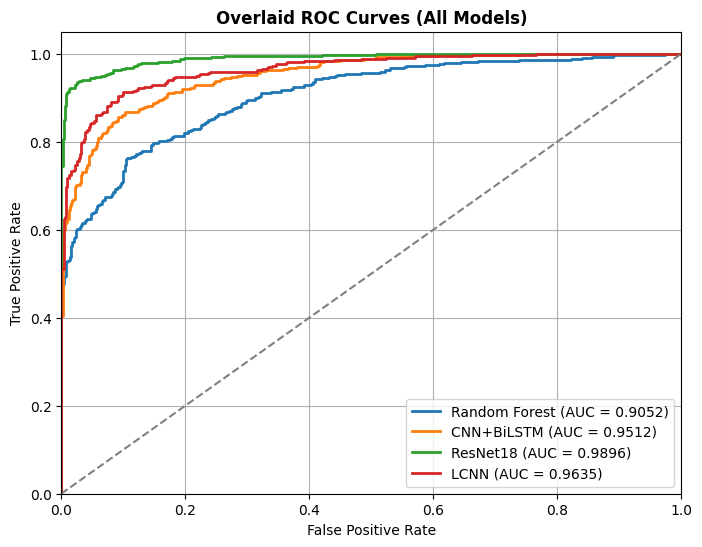

In [ ]:
# ── CELL 7b: PLOT COMPARATIVE ROC CURVES ──────────────────────────────────────

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
for name, prob in [("Random Forest", prob_tuned), ("CNN+BiLSTM", prob_cnn), ("ResNet18", prob_res), ("LCNN", prob_lcnn)]:
    fpr, tpr, _ = roc_curve(y_val, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overlaid ROC Curves (All Models)', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(os.path.join(PLOT_DIR, "overlaid_roc_curves.png"), dpi=200)
plt.show()


In [ ]:
# ── CELL 7c: DEFINE PDF REPORT SETUP ─────────────────────────────────────────

from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors

def generate_pdf_report(metrics_df, save_path=None, plots_dir=PLOT_DIR):
    """
    Generates a consolidated PDF report compiling all training metrics,
    calibration data, and explainability plots.
    """
    if save_path is None:
        save_path = os.path.join(REPORT_DIR, "Deepfake_Audio_Detection_Report.pdf")

    print(f"Generating consolidated PDF report at: {save_path}")

    doc = SimpleDocTemplate(
        save_path,
        pagesize=letter,
        rightMargin=40, leftMargin=40,
        topMargin=40, bottomMargin=40
    )

    styles = getSampleStyleSheet()

    # Custom Premium styles
    title_style = ParagraphStyle(
        'DocTitle', parent=styles['Normal'], fontName='Helvetica-Bold', fontSize=24, leading=28,
        textColor=colors.HexColor('#1E293B'), alignment=1, spaceAfter=15
    )
    subtitle_style = ParagraphStyle(
        'DocSubtitle', parent=styles['Normal'], fontName='Helvetica', fontSize=12, leading=16,
        textColor=colors.HexColor('#64748B'), alignment=1, spaceAfter=30
    )
    h1_style = ParagraphStyle(
        'SectionHeading', parent=styles['Heading1'], fontName='Helvetica-Bold', fontSize=16, leading=20,
        textColor=colors.HexColor('#0F172A'), spaceBefore=15, spaceAfter=10, keepWithNext=True
    )
    body_style = ParagraphStyle(
        'BodyText', parent=styles['Normal'], fontName='Helvetica', fontSize=10.5, leading=14,
        textColor=colors.HexColor('#334155'), spaceAfter=10
    )
    cell_style = ParagraphStyle(
        'TableCell', parent=styles['Normal'], fontName='Helvetica', fontSize=9, leading=11,
        textColor=colors.HexColor('#334155')
    )
    header_cell_style = ParagraphStyle(
        'HeaderCell', parent=styles['Normal'], fontName='Helvetica-Bold', fontSize=9, leading=11,
        textColor=colors.white
    )

    story = []

    # --- PAGE 1: TITLE & EXECUTIVE SUMMARY ---
    story.append(Spacer(1, 20))
    story.append(Paragraph("Deepfake Audio Detection & Calibration", title_style))
    story.append(Paragraph("A Multi-Model Explainability & Calibration Study on ASVspoof 2019 LA Subset", subtitle_style))
    story.append(Spacer(1, 10))

    story.append(Paragraph("Executive Summary", h1_style))
    summary_text = (
        "This report evaluates and compares four machine learning and deep learning models for "
        "synthetic audio spoofing detection on the ASVspoof 2019 Logical Access (LA) database: "
        "Random Forest (RF) acting as a statistical baseline, CNN+BiLSTM, ResNet18, and Light CNN (LCNN). "
        "To ensure deployment safety and decision reliability, model confidence calibration was performed "
        "using Platt Scaling and Isotonic Regression. To make the decisions transparent, explainable "
        "AI techniques (SHAP for Random Forest, GradCAM for PyTorch neural networks) were applied."
    )
    story.append(Paragraph(summary_text, body_style))
    story.append(Spacer(1, 10))

    # Configuration Details
    story.append(Paragraph("System Constants & Parameters", h1_style))
    config_data = [
        [Paragraph("Parameter", header_cell_style), Paragraph("Value", header_cell_style)],
        [Paragraph("Audio Sample Rate", cell_style), Paragraph(f"{SAMPLE_RATE} Hz", cell_style)],
        [Paragraph("Feature Type", cell_style), Paragraph(f"MFCC (n_mfcc={N_MFCC})", cell_style)],
        [Paragraph("Window / Hop Size", cell_style), Paragraph(f"{WINDOW_MS} ms / {HOP_MS} ms", cell_style)],
        [Paragraph("Train Subset Size", cell_style), Paragraph(f"3,000 samples ({TRAIN_BONAFIDE_SIZE} Genuine, {TRAIN_SPOOF_SIZE} Spoof)", cell_style)],
        [Paragraph("Validation Subset Size", cell_style), Paragraph(f"1,000 samples ({VAL_BONAFIDE_SIZE} Genuine, {VAL_SPOOF_SIZE} Spoof)", cell_style)]
    ]
    t_config = Table(config_data, colWidths=[180, 320])
    t_config.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#3B82F6')), # Primary Blue
        ('ALIGN', (0,0), (-1,-1), 'LEFT'),
        ('BOTTOMPADDING', (0,0), (-1,0), 6),
        ('TOPPADDING', (0,0), (-1,0), 6),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#E2E8F0')),
        ('BACKGROUND', (0,1), (-1,-1), colors.HexColor('#F8FAFC')),
        ('TOPPADDING', (0,1), (-1,-1), 4),
        ('BOTTOMPADDING', (0,1), (-1,-1), 4),
    ]))
    story.append(t_config)

    # Overlaid ROC curve on page 1 if it exists
    roc_img_path = os.path.join(plots_dir, "overlaid_roc_curves.png")
    if os.path.exists(roc_img_path):
        story.append(Spacer(1, 20))
        story.append(Paragraph("Model Classification Performance", h1_style))
        story.append(Image(roc_img_path, width=450, height=200))

    story.append(PageBreak())

    # --- PAGE 2: COMPARATIVE PERFORMANCE METRICS ---
    story.append(Paragraph("Evaluation Metrics Table", h1_style))

    # Convert dataframe into table
    headers = [Paragraph(str(col), header_cell_style) for col in metrics_df.columns]
    table_rows = [headers]
    for _, row in metrics_df.iterrows():
        row_cells = []
        for val in row.values:
            if isinstance(val, float):
                cell_text = f"{val:.4f}"
            else:
                cell_text = str(val)
            row_cells.append(Paragraph(cell_text, cell_style))
        table_rows.append(row_cells)

    t_metrics = Table(table_rows, colWidths=[90, 34, 34, 34, 34, 45, 40, 48, 48, 48, 48])
    t_metrics.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#1E293B')), # Dark Slate
        ('ALIGN', (0,0), (-1,-1), 'CENTER'),
        ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
        ('BOTTOMPADDING', (0,0), (-1,-1), 4),
        ('TOPPADDING', (0,0), (-1,-1), 4),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#CBD5E1')),
        ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#F1F5F9')])
    ]))
    story.append(t_metrics)
    story.append(Spacer(1, 15))

    # Reliability diagram image
    reliability_img_path = os.path.join(plots_dir, "calibration_reliability_diagrams.png")
    if os.path.exists(reliability_img_path):
        story.append(Paragraph("Confidence Calibration Analysis", h1_style))
        story.append(Paragraph(
            "Reliability diagrams map average predicted probabilities (confidence) against the true "
            "empirical frequency of synthetic trials in each bin. Platt scaling and Isotonic regression "
            "successfully reduce Expected Calibration Error (ECE) and improve Brier score alignment.",
            body_style
        ))
        story.append(Image(reliability_img_path, width=440, height=340))

    story.append(PageBreak())

    # --- PAGE 3: EXPLAINABLE AI VISUALIZATION ---
    story.append(Paragraph("Model Interpretability & Explainability", h1_style))
    story.append(Paragraph(
        "To interpret feature dependency, SHAP values are extracted from Random Forest. For Deep Learning "
        "models, GradCAM overlays locate the spatial-temporal regions in the 2D MFCC spectrogram that drive "
        "the spoof decisions.",
        body_style
    ))
    story.append(Spacer(1, 10))

    # SHAP images
    shap_beeswarm = os.path.join(plots_dir, "shap_beeswarm.png")
    shap_waterfall = os.path.join(plots_dir, "shap_waterfall.png")

    shap_elements = []
    if os.path.exists(shap_beeswarm):
        shap_elements.append([Paragraph("<b>Global Feature Impact (SHAP Beeswarm)</b>", cell_style)])
        shap_elements.append([Image(shap_beeswarm, width=320, height=190)])
    if os.path.exists(shap_waterfall):
        shap_elements.append([Paragraph("<b>Individual Decision Path (SHAP Waterfall)</b>", cell_style)])
        shap_elements.append([Image(shap_waterfall, width=320, height=190)])

    if shap_elements:
        t_shap = Table(shap_elements, colWidths=[400])
        t_shap.setStyle(TableStyle([
            ('ALIGN', (0,0), (-1,-1), 'CENTER'),
            ('BOTTOMPADDING', (0,0), (-1,-1), 10),
        ]))
        story.append(t_shap)

    story.append(PageBreak())

    # --- PAGE 4: GRAD-CAM IMAGES ---
    story.append(Paragraph("Deep Learning GradCAM Heatmaps", h1_style))
    story.append(Paragraph(
        "Below are the GradCAM activation maps visualizing target feature map regions in the final conv layers "
        "of the deep learning architectures. High intensity regions represent the primary spectral elements "
        "responsible for labeling the sample as synthetic.",
        body_style
    ))
    story.append(Spacer(1, 10))

    # GradCAM images
    cam_images = [
        ("cnn_bilstm_gradcam.png", "CNN+BiLSTM GradCAM Output"),
        ("resnet18_gradcam.png", "ResNet18 GradCAM Output"),
        ("lcnn_gradcam.png", "LCNN GradCAM Output")
    ]

    cam_elements = []
    for filename, title in cam_images:
        path = os.path.join(plots_dir, filename)
        if os.path.exists(path):
            cam_elements.append([Paragraph(f"<b>{title}</b>", cell_style)])
            cam_elements.append([Image(path, width=420, height=170)])
            cam_elements.append([Spacer(1, 10)])

    if cam_elements:
        t_cam = Table(cam_elements, colWidths=[450])
        t_cam.setStyle(TableStyle([
            ('ALIGN', (0,0), (-1,-1), 'CENTER'),
        ]))
        story.append(t_cam)

    doc.build(story)
    print("Report generated successfully.")


In [ ]:
# ── CELL 7d: EXECUTE PDF REPORT GENERATION ───────────────────────────────────

# Generate the PDF Report in reports directory
generate_pdf_report(metrics_compiled, save_path=os.path.join(REPORT_DIR, "Deepfake_Audio_Detection_Report.pdf"))


Generating consolidated PDF report at: /content/project_outputs/reports/Deepfake_Audio_Detection_Report.pdf
Report generated successfully.


In [ ]:
# ── CELL 7e: SYNCHRONIZE FILES AND BACKUP TO DRIVE ───────────────────────────

import shutil

# Copy local output directories directly to Google Drive
drive_out = "/content/drive/MyDrive/Colab Notebooks/project_outputs"
print(f"Copying project outputs to Drive at: {drive_out}...")
shutil.copytree(OUTPUT_DIR, drive_out, dirs_exist_ok=True)

# Create zipped backup on Drive
archive_name = "/content/drive/MyDrive/Colab Notebooks/deepfake_detection_outputs_backup"
print(f"Creating zipped backup file at: {archive_name}.zip...")
shutil.make_archive(archive_name, 'zip', OUTPUT_DIR)

print("✅ Backup complete. All files saved to Google Drive and archived!")


Copying project outputs to Drive at: /content/drive/MyDrive/Colab Notebooks/project_outputs...
Creating zipped backup file at: /content/drive/MyDrive/Colab Notebooks/deepfake_detection_outputs_backup.zip...
✅ Backup complete. All files saved to Google Drive and archived!
